![Universidad Estatal Amazónica](https://i.imgur.com/7FdddzP.jpg)

# **🎓 UNIVERSIDAD ESTATAL AMAZÓNICA**

## Facultad de Ciencias de la Vida y Tecnologías

---

# 📊 MINERÍA DE DATOS

## Práctica de Aplicación – Caso de Estudio Empresarial

### **Minería de datos aplicada al análisis y predicción de ventas según sector económico y ubicación geográfica en Ecuador**


---

## 👥 Integrantes

### **Estudiantes**

- **María Angela García Toro**
- **Grefa Calapucha Johnny Guillermo**
- **Tóala Columba Estefany Gabriela**

### 👨‍🏫 Docente

**ORTEGA TENEZACA DELFIN BERNABE**

---

## 📅 Fecha

**Septiembre de 2026**

---

> ### 🔎 Tema del proyecto
> **Análisis y predicción de ventas registradas en el Servicio de Rentas Internas (SRI), considerando el sector económico y la ubicación geográfica en Ecuador.**

---

### 🧠 Tecnologías utilizadas

`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `Scikit-learn` · `Google Colab`

---

**Universidad Estatal Amazónica — Ingeniería de Tecnologías de la Información**

> *Minería de Datos · Análisis · Modelado Predictivo · Machine Learning*

# Minería de datos aplicada al análisis y predicción de ventas según sector económico y ubicación geográfica en Ecuador

## 1. Definición del problema

El análisis de información económica permite identificar patrones relacionados con el comportamiento de las ventas y compras en diferentes sectores y ubicaciones geográficas. El conjunto de datos utilizado en esta práctica contiene información agregada de ventas y compras registrada por el Servicio de Rentas Internas (SRI), desagregada por período, provincia, cantón y sector económico.

El volumen de información dificulta realizar un análisis completo únicamente mediante procedimientos manuales, por lo que resulta necesario aplicar técnicas de minería de datos que permitan explorar, transformar y analizar los registros disponibles.

En este contexto, se plantea desarrollar un proceso de minería de datos orientado al análisis del comportamiento de las ventas y a la construcción de modelos predictivos que permitan estimar las ventas del siguiente período utilizando información histórica disponible en el conjunto de datos.

El problema se centra, por tanto, en determinar qué patrones pueden identificarse en las ventas según el sector económico y la ubicación geográfica, y qué tan adecuadamente diferentes técnicas de minería de datos permiten realizar una predicción de las ventas del siguiente período.



## 2. Objetivo general

Desarrollar un proceso de minería de datos para analizar y predecir las ventas del siguiente período, utilizando información histórica de ventas, compras, sector económico y ubicación geográfica registrada por el Servicio de Rentas Internas (SRI) durante el período enero-junio de 2026.

## 2.1 Objetivos específicos

- Explorar y caracterizar el conjunto de datos de ventas y compras mediante técnicas de análisis exploratorio, identificando valores nulos, duplicados, valores atípicos, distribuciones y relaciones entre variables.

- Preprocesar y transformar los datos mediante técnicas de limpieza, codificación y feature engineering para generar variables históricas que permitan la construcción del modelo predictivo.

- Implementar y comparar tres modelos de regresión mediante métricas de evaluación y validación cruzada para analizar su capacidad de predicción de las ventas del siguiente período.

## 3. Recolección y exploración de datos
Para el desarrollo de la práctica se utilizó el conjunto de datos sri_ventas_2026.csv, correspondiente a información agregada de ventas y compras registrada por el Servicio de Rentas Internas (SRI).

El conjunto de datos contiene información correspondiente al año 2026 y permite analizar los registros según período, sector económico, provincia y cantón, además de diferentes variables relacionadas con ventas, compras, exportaciones e importaciones.

El archivo fue utilizado como fuente de datos para las etapas de exploración, preprocesamiento y modelado de la presente práctica. https://www.sri.gob.ec/datasets

In [ ]:
# ==========================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

# Librerías para manejo y análisis de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para minería de datos y aprendizaje automático
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    silhouette_score
)

# Configuración para mostrar todas las columnas
pd.set_option('display.max_columns', None)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 3.1 Cargar el dataset

In [ ]:
# Importamos Google Drive para poder acceder a los archivos
# almacenados en nuestra cuenta desde Google Colab.
from google.colab import drive

# Montamos Google Drive en el entorno de Colab.
# Esto permite acceder a los archivos almacenados en:
# /content/drive/MyDrive/
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importar la biblioteca pandas para la manipulación y análisis de datos
import pandas as pd

# Definir la ruta donde se encuentra almacenado el dataset en Google Drive
ruta = "/content/drive/MyDrive/sri_ventas_2026.csv"

# Cargar el archivo CSV en un DataFrame
# sep="|" indica que las columnas están separadas por el carácter |
# encoding="latin1" permite interpretar correctamente caracteres especiales
df = pd.read_csv(
    ruta,
    sep="|",
    encoding="latin1"
)

# Confirmar que el dataset fue cargado correctamenteprint("Dataset cargado correctamente.")
print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [ ]:
# Conocer el tamaño del dataset, esto nos permite ver cuantas filas y columnas tenemos
print("Número de registros:", df.shape[0])
print("Número de variables:", df.shape[1])

Número de registros: 25339
Número de variables: 16


## 3.2 Ver las primeras filas


In [ ]:
# Esto nos permitirá comprobar que las columnas y los datos se cargaron correctamente.

df.head()

,AÑO,MES,CODIGO_SECTOR_N1,PROVINCIA,CANTON,VENTAS_NETAS_TARIFA_GRAVADA,VENTAS_NETAS_TARIFA_0,VENTAS_NETAS_TARIFA_VARIABLE,VENTAS_NETAS_TARIFA_5,EXPORTACIONES,COMPRAS_NETAS_TARIFA_GRAVADA,COMPRAS_NETAS_TARIFA_0,IMPORTACIONES,COMPRAS_RISE,TOTAL_COMPRAS,TOTAL_VENTAS
0,2026,1,N,MORONA SANTIAGO,MORONA,"178361,7700","7158,0000","0,0000","41508,6100","0,0000","121531,9400","28536,8000","2,0000","4968,5000","157865,9100","227028,3800"
1,2026,1,M,MORONA SANTIAGO,LOGROÑO,"68603,7000","1729,2500","0,0000","11868,8300","0,0000","85945,2800","2509,0800","0,0000","0,0000","103520,4900","82201,7800"
2,2026,1,N,ZAMORA CHINCHIPE,CENTINELA DEL CONDOR,"61274,9500","500,0000","0,0000","0,0000","0,0000","80249,0400","16841,2700","0,0000","0,0000","97090,3100","61774,9500"
3,2026,1,M,SANTA ELENA,LA LIBERTAD,"1175173,5700","270977,5500","0,0000","760,0000","0,0000","1762955,9800","191268,7500","2349,9100","31127,7100","2038720,6600","1446911,1200"
4,2026,1,G,PICHINCHA,PEDRO VICENTE MALDONADO,"2055943,3100","1131223,7000","0,0000","137241,1400","0,0000","2551843,7900","761677,7000","2352,5900","26625,5400","3492521,3000","3324408,1500"


**Interpretación:** La visualización de las primeras filas del conjunto de datos permitió comprobar que la información fue cargada correctamente en Google Colab. Se identificaron las variables correspondientes al año, mes, sector económico, provincia, cantón, ventas, compras, exportaciones e importaciones. Los registros muestran datos correspondientes a enero de 2026 y presentan valores numéricos en las variables económicas, confirmando que la estructura del dataset es adecuada para continuar con el proceso de exploración y análisis.

In [ ]:
print("Número de registros:", df.shape[0])
print("Número de variables:", df.shape[1])

Número de registros: 25339
Número de variables: 16


##  3.3 Identificar las variables (Columnas)

In [ ]:
# Mostrar los nombres de todas las columnas del dataset
# Permite identificar las variables disponibles para el análisis.
df.columns

Index(['AÑO', 'MES', 'CODIGO_SECTOR_N1', 'PROVINCIA', 'CANTON',
       'VENTAS_NETAS_TARIFA_GRAVADA', 'VENTAS_NETAS_TARIFA_0',
       'VENTAS_NETAS_TARIFA_VARIABLE', 'VENTAS_NETAS_TARIFA_5',
       'EXPORTACIONES', 'COMPRAS_NETAS_TARIFA_GRAVADA',
       'COMPRAS_NETAS_TARIFA_0', 'IMPORTACIONES', 'COMPRAS_RISE',
       'TOTAL_COMPRAS', 'TOTAL_VENTAS'],
      dtype='object')

## 3.4 Conocer el tipo de dato de cada variable

In [ ]:
# Mostrar el tipo de dato de cada variable del dataset.
# Permite identificar qué columnas son numéricas y cuáles son de tipo texto.
df.dtypes

,0
AÑO,int64
MES,int64
CODIGO_SECTOR_N1,object
PROVINCIA,object
CANTON,object
VENTAS_NETAS_TARIFA_GRAVADA,object
VENTAS_NETAS_TARIFA_0,object
VENTAS_NETAS_TARIFA_VARIABLE,object
VENTAS_NETAS_TARIFA_5,object
EXPORTACIONES,object


**Interpretación:** La revisión de los tipos de datos permitió identificar que las variables AÑO y MES fueron reconocidas como datos numéricos (int64), mientras que las variables de ubicación, sector económico y valores financieros fueron cargadas inicialmente como tipo texto (object). Esto permitió detectar la necesidad de realizar una conversión de las variables económicas a formato numérico antes de efectuar los análisis estadísticos, la visualización y el entrenamiento de los modelos de minería de datos.

## 3.5 Información general del dataset

In [ ]:
# Mostrar información general del dataset.
# Permite conocer:
# - El número de registros.
# - El número de variables.
# - Los nombres de las columnas.
# - La cantidad de valores no nulos.
# - El tipo de dato de cada variable.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25339 entries, 0 to 25338
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   AÑO                           25339 non-null  int64 
 1   MES                           25339 non-null  int64 
 2   CODIGO_SECTOR_N1              25339 non-null  object
 3   PROVINCIA                     25339 non-null  object
 4   CANTON                        25339 non-null  object
 5   VENTAS_NETAS_TARIFA_GRAVADA   25339 non-null  object
 6   VENTAS_NETAS_TARIFA_0         25339 non-null  object
 7   VENTAS_NETAS_TARIFA_VARIABLE  25339 non-null  object
 8   VENTAS_NETAS_TARIFA_5         25339 non-null  object
 9   EXPORTACIONES                 25339 non-null  object
 10  COMPRAS_NETAS_TARIFA_GRAVADA  25339 non-null  object
 11  COMPRAS_NETAS_TARIFA_0        25339 non-null  object
 12  IMPORTACIONES                 25339 non-null  object
 13  COMPRAS_RISE    

La función df.info() permitió verificar la estructura general del conjunto de datos, identificando 25.339 registros y 16 variables, sin valores nulos, debido a que las 16 columnas presentan 25.339 valores no nulos. Las variables AÑO y MES fueron reconocidas como datos enteros (int64), mientras que las 14 variables restantes fueron identificadas inicialmente como tipo objeto (object). Entre estas se encuentran las variables categóricas de sector, provincia y cantón, así como las variables económicas relacionadas con ventas, compras, exportaciones e importaciones. Esta revisión permitió determinar que las variables económicas requerían una conversión al formato numérico antes de continuar con el análisis estadístico y el modelamiento.

## 4. Estadistica descriptiva

In [ ]:
# Generar estadísticas descriptivas de las variables numéricas del dataset.
# Permite conocer valores como:
# - Cantidad de registros.
# - Promedio (mean).
# - Desviación estándar (std).
# - Valor mínimo (min).
# - Cuartiles (25%, 50% y 75%).
# - Valor máximo (max).
# Facilita una primera revisión de la distribución y comportamiento de los datos.
df.describe()

,AÑO,MES
count,25339.0,25339.000000
mean,2026.0,3.497218
std,0.0,1.709004
min,2026.0,1.000000
25%,2026.0,2.000000
50%,2026.0,3.000000
75%,2026.0,5.000000
max,2026.0,6.000000


**Interpretación:** El análisis descriptivo de las variables temporales muestra que el conjunto de datos contiene 25.339 registros correspondientes al año 2026. La variable AÑO presenta un valor constante de 2026 en todos los registros, mientras que la variable MES presenta valores entre 1 y 6, correspondientes al período de enero a junio de 2026. La media de la variable MES es 3,50, con una desviación estándar de 1,71, lo que refleja la distribución de los registros a lo largo de los seis meses analizados. Los percentiles muestran que el 25 % de los registros corresponde hasta febrero, el 50 % hasta marzo y el 75 % hasta mayo.

## 5. Identificar valores nulos

In [ ]:
# Contar la cantidad de valores nulos o faltantes en cada variable del dataset.
# Permite identificar columnas que presentan datos incompletos
# y determinar si es necesario realizar un tratamiento de valores faltantes.
df.isnull().sum()

,0
AÑO,0
MES,0
CODIGO_SECTOR_N1,0
PROVINCIA,0
CANTON,0
VENTAS_NETAS_TARIFA_GRAVADA,0
VENTAS_NETAS_TARIFA_0,0
VENTAS_NETAS_TARIFA_VARIABLE,0
VENTAS_NETAS_TARIFA_5,0
EXPORTACIONES,0


## 5.1 Porcentaje de valores nulos

In [ ]:
# Calcular el porcentaje de valores nulos en cada variable del dataset.
# Se divide la cantidad de valores nulos de cada columna entre el total de registros
# y se multiplica por 100 para obtener el porcentaje.
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

porcentaje_nulos

,0
AÑO,0.0
MES,0.0
CODIGO_SECTOR_N1,0.0
PROVINCIA,0.0
CANTON,0.0
VENTAS_NETAS_TARIFA_GRAVADA,0.0
VENTAS_NETAS_TARIFA_0,0.0
VENTAS_NETAS_TARIFA_VARIABLE,0.0
VENTAS_NETAS_TARIFA_5,0.0
EXPORTACIONES,0.0


## 6. Registros duplicados

In [ ]:
# Contar la cantidad de registros duplicados en el dataset.
# La función duplicated() identifica las filas que están completamente repetidas.
duplicados = df.duplicated().sum()

# Mostrar la cantidad total de registros duplicados encontrados.
print("Cantidad de registros duplicados:", duplicados)

# Calcular y mostrar el porcentaje de registros duplicados
# con respecto al total de registros del dataset.
print("Porcentaje de registros duplicados:", (duplicados / len(df)) * 100, "%")

Cantidad de registros duplicados: 0
Porcentaje de registros duplicados: 0.0 %


## Interpretación:
Se aplicó la función duplicated() de Pandas para identificar registros completamente repetidos. El análisis determinó la existencia de 0 registros duplicados, equivalente al 0,0 % del total de 25.339 registros. En consecuencia, no fue necesario eliminar registros por duplicidad durante esta etapa de exploración.

## 7. Identificación de valores atípicos

In [ ]:
# Mostrar un título para identificar la información que se presentará.
print("Tipo de dato de cada variable:\n")

# Mostrar el tipo de dato correspondiente a cada variable del dataset.
# Permite identificar qué columnas son numéricas y cuáles son de tipo texto.
print(df.dtypes)

Tipo de dato de cada variable:

AÑO                              int64
MES                              int64
CODIGO_SECTOR_N1                object
PROVINCIA                       object
CANTON                          object
VENTAS_NETAS_TARIFA_GRAVADA     object
VENTAS_NETAS_TARIFA_0           object
VENTAS_NETAS_TARIFA_VARIABLE    object
VENTAS_NETAS_TARIFA_5           object
EXPORTACIONES                   object
COMPRAS_NETAS_TARIFA_GRAVADA    object
COMPRAS_NETAS_TARIFA_0          object
IMPORTACIONES                   object
COMPRAS_RISE                    object
TOTAL_COMPRAS                   object
TOTAL_VENTAS                    object
dtype: object


## 8. Comprobar el formato de los valores económicos

In [ ]:
# Mostrar un mensaje indicando que se presentarán ejemplos de la variable TOTAL_VENTAS.
print("Ejemplos de TOTAL_VENTAS:")

# Mostrar los primeros 10 registros de la columna TOTAL_VENTAS.
# El parámetro index=False evita mostrar el índice de las filas.
# Permite observar cómo están representados los valores antes de realizar
# las transformaciones necesarias durante el preprocesamiento.
print(df["TOTAL_VENTAS"].head(10).to_string(index=False))

Ejemplos de TOTAL_VENTAS:
 227028,3800
  82201,7800
  61774,9500
1446911,1200
3324408,1500
 816084,8000
   9820,4300
  27650,9100
3315786,4000
6689415,1400


**Interpretación:** La visualización de los primeros 10 registros de la variable TOTAL_VENTAS permitió comprobar cómo se encuentran representados inicialmente los valores económicos en el dataset. Se observa que los datos utilizan coma como separador decimal, por ejemplo, 227028,3800 y 82201,7800. Debido a este formato, los valores fueron identificados inicialmente como tipo object, por lo que fue necesario realizar una transformación al formato numérico antes de efectuar operaciones estadísticas, análisis de distribución y modelamiento predictivo.

## 9. Preparar la identificación de outliers

In [ ]:
# Crear una copia del dataset original para realizar las transformaciones
# sin modificar directamente el DataFrame original.
df_trabajo = df.copy()

# Definir las variables económicas que contienen valores monetarios
# y que deben convertirse a un formato numérico para el análisis.
columnas_economicas = [

    "VENTAS_NETAS_TARIFA_GRAVADA",
    "VENTAS_NETAS_TARIFA_0",
    "VENTAS_NETAS_TARIFA_VARIABLE",
    "VENTAS_NETAS_TARIFA_5",
    "EXPORTACIONES",
    "COMPRAS_NETAS_TARIFA_GRAVADA",
    "COMPRAS_NETAS_TARIFA_0",
    "IMPORTACIONES",
    "COMPRAS_RISE",
    "TOTAL_COMPRAS",
    "TOTAL_VENTAS"
]

# Recorrer cada una de las variables económicas seleccionadas.
for columna in columnas_economicas:

    # Reemplazar la coma decimal por un punto y convertir los valores
    # de texto a formato numérico.
    # errors="coerce" convierte en NaN aquellos valores que no puedan
    # ser transformados correctamente.
    df_trabajo[columna] = pd.to_numeric(
        df_trabajo[columna].str.replace(",", ".", regex=False),
        errors="coerce"
    )

# Confirmar que la conversión de las variables fue realizada.
print("Conversión realizada.")

# Mostrar los tipos de datos de las variables económicas después
# de la conversión para verificar que sean numéricas.
print(df_trabajo[columnas_economicas].dtypes)

Conversión realizada.
VENTAS_NETAS_TARIFA_GRAVADA     float64
VENTAS_NETAS_TARIFA_0           float64
VENTAS_NETAS_TARIFA_VARIABLE    float64
VENTAS_NETAS_TARIFA_5           float64
EXPORTACIONES                   float64
COMPRAS_NETAS_TARIFA_GRAVADA    float64
COMPRAS_NETAS_TARIFA_0          float64
IMPORTACIONES                   float64
COMPRAS_RISE                    float64
TOTAL_COMPRAS                   float64
TOTAL_VENTAS                    float64
dtype: object


## 9.1 Detectar outliers mediante IQR

In [ ]:
# Identificar valores atípicos mediante el método del rango intercuartílico (IQR).
# El método IQR permite detectar valores que se encuentran fuera del rango
# esperado de cada variable económica.

# Crear una lista para almacenar los resultados de los valores atípicos.
resultados_outliers = []

# Recorrer cada una de las variables económicas.
for columna in columnas_economicas:

    # Calcular el primer cuartil (Q1), correspondiente al percentil 25%.
    Q1 = df_trabajo[columna].quantile(0.25)

    # Calcular el tercer cuartil (Q3), correspondiente al percentil 75%.
    Q3 = df_trabajo[columna].quantile(0.75)

    # Calcular el rango intercuartílico (IQR).
    # Representa la diferencia entre el tercer y el primer cuartil.
    IQR = Q3 - Q1

    # Establecer los límites para identificar valores atípicos.
    # Los valores que estén por debajo o por encima de estos límites
    # serán considerados posibles outliers.
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Contar los registros que se encuentran fuera de los límites establecidos.
    cantidad_outliers = (
        (df_trabajo[columna] < limite_inferior) |
        (df_trabajo[columna] > limite_superior)
    ).sum()

    # Calcular el porcentaje de valores atípicos respecto al total de registros.
    porcentaje_outliers = (cantidad_outliers / len(df_trabajo)) * 100

    # Guardar los resultados obtenidos para cada variable.
    resultados_outliers.append({
        "Variable": columna,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Cantidad de outliers": cantidad_outliers,
        "Porcentaje de outliers": porcentaje_outliers
    })

# Convertir los resultados obtenidos en un DataFrame
# para facilitar su análisis y presentación.
tabla_outliers = pd.DataFrame(resultados_outliers)

# Mostrar la tabla con los resultados de los valores atípicos.
tabla_outliers

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad de outliers,Porcentaje de outliers
0,VENTAS_NETAS_TARIFA_GRAVADA,910.000,138861.275,137951.275,-206016.9125,3.457882e+05,4187,16.523935
1,VENTAS_NETAS_TARIFA_0,400.000,166795.540,166395.540,-249193.3100,4.163888e+05,4455,17.581594
2,VENTAS_NETAS_TARIFA_VARIABLE,0.000,0.000,0.000,0.0000,0.000000e+00,973,3.839931
3,VENTAS_NETAS_TARIFA_5,0.000,0.000,0.000,0.0000,0.000000e+00,5022,19.819251
4,EXPORTACIONES,0.000,0.000,0.000,0.0000,0.000000e+00,2719,10.730494
5,COMPRAS_NETAS_TARIFA_GRAVADA,3532.215,233567.950,230035.735,-341521.3875,5.786216e+05,4065,16.042464
6,COMPRAS_NETAS_TARIFA_0,538.635,97251.140,96712.505,-144530.1225,2.423199e+05,4528,17.869687
7,IMPORTACIONES,0.000,0.000,0.000,0.0000,0.000000e+00,5852,23.094834
8,COMPRAS_RISE,0.000,6590.475,6590.475,-9885.7125,1.647619e+04,4370,17.246142
9,TOTAL_COMPRAS,5728.695,405865.040,400136.345,-594475.8225,1.006070e+06,4195,16.555507


**Inrerpretación:**
Mediante el método del rango intercuartílico (IQR) se identificaron valores potencialmente atípicos en las variables económicas del conjunto de datos. Los porcentajes obtenidos varían según la variable, alcanzando valores entre aproximadamente 3,84 % y 23,09 %. Estos registros no fueron eliminados automáticamente, debido a que, en el contexto económico analizado, los valores extremos pueden representar observaciones reales asociadas a diferentes niveles de actividad comercial. Por esta razón, los resultados serán considerados durante la etapa de preprocesamiento y modelado.

## 9.2 Visualizar los outliers

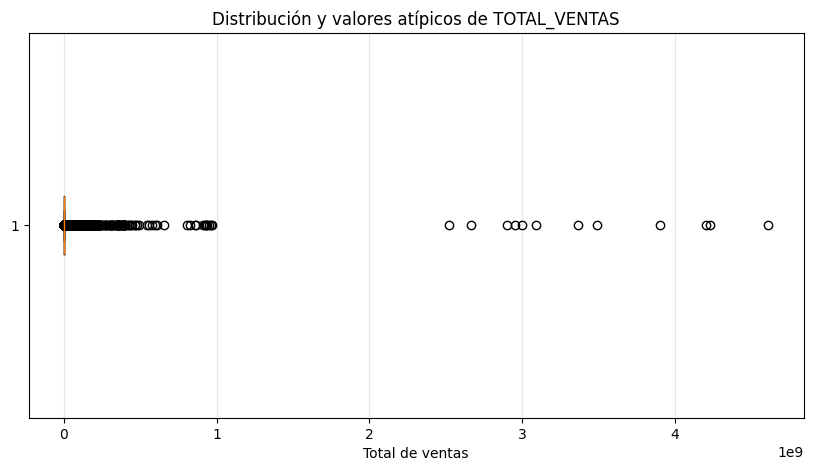

In [ ]:
# Importar la biblioteca Matplotlib para generar gráficos.
import matplotlib.pyplot as plt

# Definir el tamaño de la figura para mejorar su visualización.
plt.figure(figsize=(10, 5))

# Generar un diagrama de caja (boxplot) para la variable TOTAL_VENTAS.
# El parámetro vert=False presenta el gráfico en orientación horizontal.
# Permite visualizar la distribución, los cuartiles y posibles valores atípicos.
plt.boxplot(
    df_trabajo["TOTAL_VENTAS"],
    vert=False
)

# Establecer el título del gráfico.
plt.title("Distribución y valores atípicos de TOTAL_VENTAS")

# Etiquetar el eje X con el nombre de la variable analizada.
plt.xlabel("Total de ventas")

# Agregar una cuadrícula vertical para facilitar la interpretación de los valores.
plt.grid(axis="x", alpha=0.3)

# Mostrar el gráfico.
plt.show()

El diagrama de caja de la variable TOTAL_VENTAS evidencia una distribución con marcada asimetría positiva. La mayor parte de las observaciones se concentra en valores inferiores, mientras que se identifican numerosos valores alejados del rango intercuartílico, incluyendo algunas observaciones con valores considerablemente elevados. Estos registros fueron considerados valores potencialmente atípicos mediante el criterio IQR. Sin embargo, debido a la naturaleza económica del conjunto de datos, no se asumió que dichos valores correspondieran a errores, por lo que no fueron eliminados de manera automática.

## 10. Primera visualización requerida: distribución de ventas

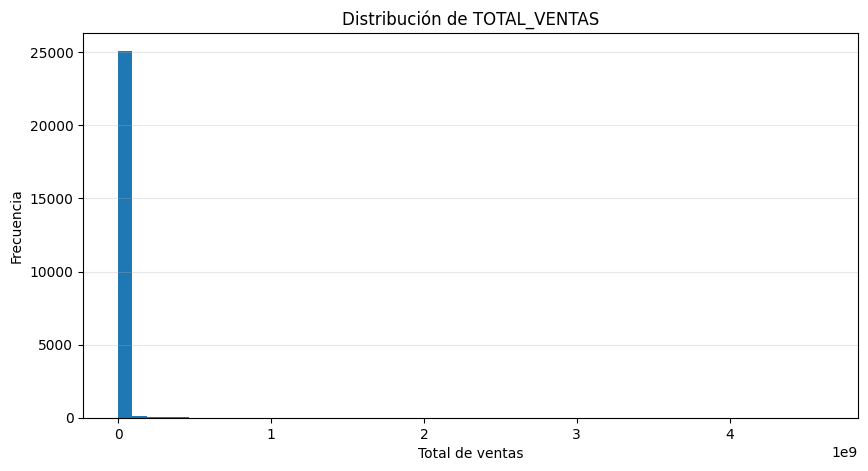

In [ ]:
# Definir el tamaño de la figura para mejorar su visualización.
plt.figure(figsize=(10, 5))

# Generar un histograma de la variable TOTAL_VENTAS.
# El parámetro bins=50 divide los valores en 50 intervalos
# para observar con mayor detalle su distribución.
plt.hist(
    df_trabajo["TOTAL_VENTAS"],
    bins=50
)

# Establecer el título del gráfico.
plt.title("Distribución de TOTAL_VENTAS")

# Etiquetar el eje X con la variable analizada.
plt.xlabel("Total de ventas")

# Etiquetar el eje Y indicando la frecuencia de los registros.
plt.ylabel("Frecuencia")

# Agregar una cuadrícula horizontal para facilitar la lectura
# de la frecuencia de los valores.
plt.grid(axis="y", alpha=0.3)

# Mostrar el histograma.
plt.show()

El histograma de TOTAL_VENTAS muestra una distribución con marcada asimetría positiva. La mayor concentración de registros se encuentra en los valores inferiores de ventas, mientras que una cantidad reducida de observaciones presenta valores considerablemente superiores. Esta distribución es consistente con la presencia de valores extremos identificados mediante el método IQR y evidencia una alta dispersión en los niveles de ventas registrados.

## 11. Segunda visualización: ventas por provincia

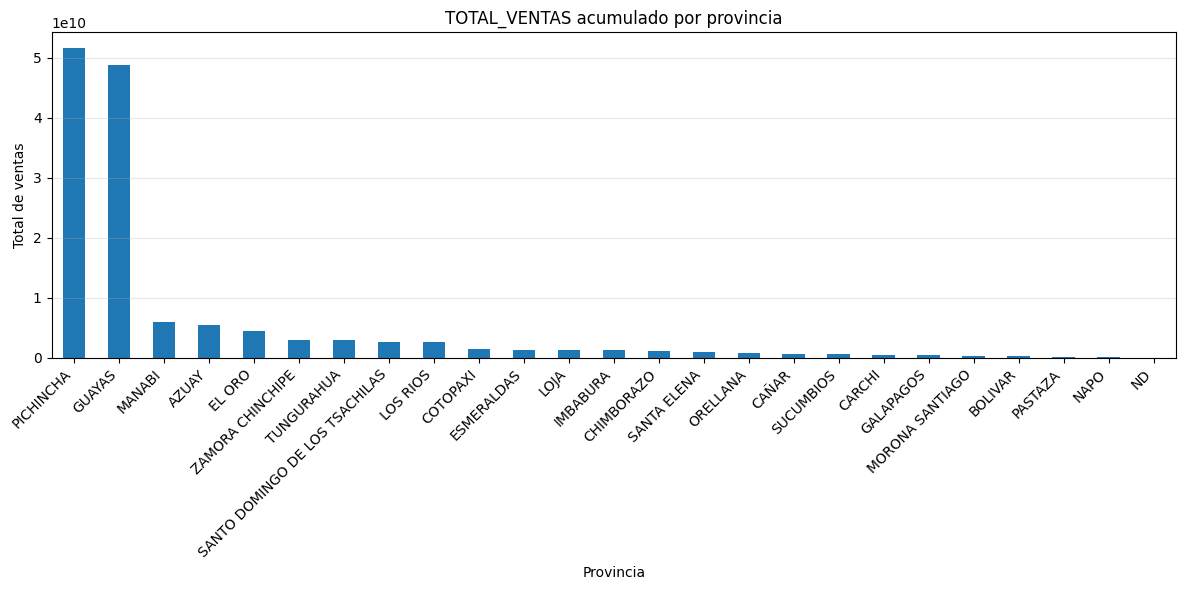

In [ ]:
# Agrupar los registros por provincia y calcular el total acumulado
# de ventas para cada provincia.
ventas_provincia = (
    df_trabajo
    .groupby("PROVINCIA")["TOTAL_VENTAS"]
    .sum()
    .sort_values(ascending=False)
)

# Definir el tamaño de la figura para facilitar la visualización.
plt.figure(figsize=(12, 6))

ventas_provincia.plot(kind="bar")

plt.title("TOTAL_VENTAS acumulado por provincia")
plt.xlabel("Provincia")
plt.ylabel("Total de ventas")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

La distribución acumulada de TOTAL_VENTAS por provincia evidencia diferencias importantes en el volumen de ventas registrado durante el período analizado. Pichincha y Guayas concentran los valores acumulados más elevados, mientras que el resto de provincias presenta niveles considerablemente inferiores. Este comportamiento evidencia que la ubicación geográfica constituye una variable relevante para caracterizar la distribución de las ventas y justifica su consideración dentro del análisis de minería de datos.

## 12. Tercera visualización: evolución mensual de las ventas

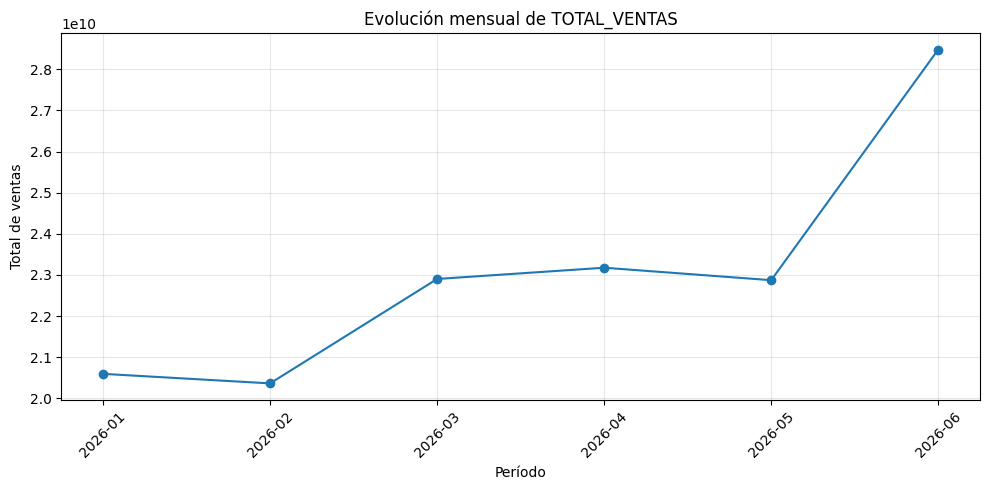

In [ ]:
# Agrupar los registros por año y mes y calcular el total acumulado
# de ventas para cada período.
ventas_mes = (

    df_trabajo
    .groupby(["AÑO", "MES"])["TOTAL_VENTAS"]
    .sum()
    .reset_index()

)

# Crear una nueva variable que combine el año y el mes
# para formar un período con el formato AAAA-MM.
ventas_mes["PERIODO"] = (

    ventas_mes["AÑO"].astype(str)
    + "-"
    + ventas_mes["MES"].astype(str).str.zfill(2)

)

# Definir el tamaño de la figura para facilitar su visualización.
plt.figure(figsize=(10, 5))

# Generar un gráfico de líneas para representar la evolución
# mensual del total de ventas.
plt.plot(
    ventas_mes["PERIODO"],
    ventas_mes["TOTAL_VENTAS"],
    marker="o"
)

# Establecer el título del gráfico.
plt.title("Evolución mensual de TOTAL_VENTAS")

# Etiquetar el eje X con el período analizado.
plt.xlabel("Período")

# Etiquetar el eje Y con el total acumulado de ventas.
plt.ylabel("Total de ventas")

# Rotar las etiquetas del eje X para facilitar su lectura.
plt.xticks(rotation=45)

# Agregar una cuadrícula para facilitar la interpretación
# de la evolución de las ventas.
plt.grid(True, alpha=0.3)

# Ajustar automáticamente los elementos del gráfico
# para evitar que las etiquetas queden cortadas.
plt.tight_layout()

# Mostrar el gráfico.
plt.show()

La evolución mensual de TOTAL_VENTAS evidencia variaciones durante el período enero-junio de 2026. Se observa una ligera disminución entre enero y febrero, seguida de un incremento en marzo y una variación moderada entre abril y mayo. En junio se registra un incremento considerable del volumen acumulado de ventas respecto del mes anterior. Este comportamiento temporal constituye un elemento relevante para el análisis posterior y para la construcción de variables históricas orientadas a la predicción del siguiente período.

## 13. Guardar un resumen del EDA

In [ ]:
# Generar estadísticas descriptivas de las variables económicas seleccionadas.
# El método describe() calcula medidas como cantidad de registros, promedio,
# desviación estándar, valores mínimo y máximo, y cuartiles.
# El método .T transpone la tabla para presentar cada variable como una fila.
resumen_economico = df_trabajo[columnas_economicas].describe().T

# Mostrar el resumen estadístico de las variables económicas.
resumen_economico

,count,mean,std,min,25%,50%,75%,max
VENTAS_NETAS_TARIFA_GRAVADA,25339.0,2.692779e+06,5.141368e+07,0.0,910.000,15789.55,138861.275,2.858987e+09
VENTAS_NETAS_TARIFA_0,25339.0,1.898479e+06,1.886394e+07,0.0,400.000,15500.52,166795.540,9.101442e+08
VENTAS_NETAS_TARIFA_VARIABLE,25339.0,4.792471e+03,1.833670e+05,0.0,0.000,0.00,0.000,1.819485e+07
VENTAS_NETAS_TARIFA_5,25339.0,7.199725e+04,1.282663e+06,0.0,0.000,0.00,0.000,5.422993e+07
EXPORTACIONES,25339.0,7.934389e+05,1.500405e+07,0.0,0.000,0.00,0.000,1.011390e+09
COMPRAS_NETAS_TARIFA_GRAVADA,25339.0,2.097825e+06,3.097563e+07,0.0,3532.215,32876.53,233567.950,1.651643e+09
COMPRAS_NETAS_TARIFA_0,25339.0,1.527317e+06,2.090353e+07,0.0,538.635,10050.73,97251.140,2.107593e+09
IMPORTACIONES,25339.0,5.855536e+05,1.382500e+07,0.0,0.000,0.00,0.000,6.764138e+08
COMPRAS_RISE,25339.0,4.304979e+04,5.298912e+05,0.0,0.000,144.75,6590.475,6.663584e+07
TOTAL_COMPRAS,25339.0,4.352645e+06,6.146933e+07,0.0,5728.695,56497.15,405865.040,2.834050e+09


La estadística descriptiva evidencia una elevada dispersión en las variables económicas analizadas. En particular, TOTAL_VENTAS presenta una media de aproximadamente 5,46 millones y una mediana de 56.054,83, mientras que su valor máximo alcanza aproximadamente 4.611,34 millones. La diferencia entre media, mediana y valores máximos evidencia una distribución altamente asimétrica y la presencia de observaciones con volúmenes de ventas considerablemente superiores al comportamiento central del conjunto de datos. Un comportamiento similar se observa en otras variables económicas.

## 14. Crear la variable objetivo futura

In [ ]:
# Crear una copia del DataFrame previamente procesado para trabajar
# en la construcción del modelo sin modificar el dataset original.
df_modelo = df_trabajo.copy()

# Ordenar los registros por provincia, cantón, sector económico,
# año y mes.
# Este orden facilita el análisis de la evolución temporal de las ventas
# dentro de cada ubicación y sector económico.
df_modelo = df_modelo.sort_values(
    ["PROVINCIA", "CANTON", "CODIGO_SECTOR_N1", "AÑO", "MES"]
).reset_index(drop=True)

print("Datos ordenados correctamente.")
print("Filas:", len(df_modelo))
print("Columnas:", len(df_modelo.columns))

Datos ordenados correctamente.
Filas: 25339
Columnas: 16


## 15. Crear la variable objetivo del siguiente período

In [ ]:
# Crear la variable objetivo TOTAL_VENTAS_FUTURA.
# Esta variable representa el total de ventas del siguiente período
# para la misma provincia, cantón y sector económico.
df_modelo["TOTAL_VENTAS_FUTURA"] = (

    df_modelo
    # Agrupar los registros por provincia, cantón y sector económico
    # para mantener la correspondencia entre cada unidad de análisis.
    .groupby(["PROVINCIA", "CANTON", "CODIGO_SECTOR_N1"])["TOTAL_VENTAS"]

    # Desplazar los valores una posición hacia arriba dentro de cada grupo.
    # De esta manera, cada registro queda asociado con las ventas
    # del período siguiente.
    .shift(-1)

)

# Mostrar las primeras 10 filas para verificar que la variable
# TOTAL_VENTAS_FUTURA fue creada correctamente.
print(df_modelo[
    [
        "PROVINCIA",
        "CANTON",
        "CODIGO_SECTOR_N1",
        "AÑO",
        "MES",
        "TOTAL_VENTAS",
        "TOTAL_VENTAS_FUTURA"
    ]
].head(10))

  PROVINCIA                 CANTON CODIGO_SECTOR_N1   AÑO  MES  TOTAL_VENTAS  \
0     AZUAY  CAMILO PONCE ENRIQUEZ                A  2026    1     111286.55   
1     AZUAY  CAMILO PONCE ENRIQUEZ                A  2026    2     127767.12   
2     AZUAY  CAMILO PONCE ENRIQUEZ                A  2026    3     147680.33   
3     AZUAY  CAMILO PONCE ENRIQUEZ                A  2026    4     201353.04   
4     AZUAY  CAMILO PONCE ENRIQUEZ                A  2026    5     220776.63   
5     AZUAY  CAMILO PONCE ENRIQUEZ                A  2026    6    1366761.36   
6     AZUAY  CAMILO PONCE ENRIQUEZ                B  2026    1   11822513.52   
7     AZUAY  CAMILO PONCE ENRIQUEZ                B  2026    2    4674220.18   
8     AZUAY  CAMILO PONCE ENRIQUEZ                B  2026    3    9723876.14   
9     AZUAY  CAMILO PONCE ENRIQUEZ                B  2026    4   11929971.10   

   TOTAL_VENTAS_FUTURA  
0            127767.12  
1            147680.33  
2            201353.04  
3            220776

**Interpretación:** La tabla muestra la asociación entre las ventas actuales y las ventas correspondientes al período siguiente mediante la variable TOTAL_VENTAS_FUTURA. Para cada combinación de provincia, cantón y sector económico, el valor de ventas del mes siguiente se utiliza como variable objetivo para el modelo predictivo. Se observa que, cuando existe información del período posterior, se asigna el valor correspondiente a TOTAL_VENTAS_FUTURA; mientras que en los registros donde no existe un período futuro disponible, se presenta un valor nulo (NaN). Esta transformación permite plantear el problema como una predicción de ventas del siguiente período, utilizando como referencia la información histórica disponible.

## 16. Comprobar continuidad temporal

In [ ]:
# Agrupar los registros por provincia, cantón y sector económico
# para analizar cuántos meses existen en cada grupo y cuál es
# el primer y último mes registrado.
meses_por_grupo = (
    df_modelo
    .groupby(["PROVINCIA", "CANTON", "CODIGO_SECTOR_N1"])["MES"]
    .agg(["count", "min", "max"])
)

print("Número de grupos:", len(meses_por_grupo))

# Mostrar cuántos grupos contienen determinada cantidad de registros.
# Esto permite comprobar la disponibilidad de información mensual
# dentro de cada combinación de provincia, cantón y sector económico.
print("\nCantidad de registros por grupo:")
print(meses_por_grupo["count"].value_counts().sort_index())

# Mostrar el rango de meses registrado en los diferentes grupos.
# Permite verificar el período temporal disponible en el dataset.
print("\nRango de meses encontrado:")
print(meses_por_grupo[["min", "max"]].drop_duplicates())

Número de grupos: 4300

Cantidad de registros por grupo:
count
1      52
2      17
3      14
4      29
5      33
6    4155
Name: count, dtype: int64

Rango de meses encontrado:
                                                   min  max
PROVINCIA  CANTON                CODIGO_SECTOR_N1          
AZUAY      CAMILO PONCE ENRIQUEZ A                   1    6
                                 V                   1    4
           EL PAN                A                   6    6
                                 P                   3    6
                                 V                   1    5
           GUACHAPALA            Q                   2    6
           NABON                 B                   1    3
CARCHI     TULCAN                U                   1    2
                                 V                   2    2
EL ORO     PIÑAS                 T                   4    6
           PORTOVELO             T                   2    3
GUAYAS     NARANJITO             V         

**Interpretación:** La agrupación de los registros por provincia, cantón y código de sector económico permitió identificar 4.300 grupos y comprobar la cantidad de registros disponibles para cada combinación. Se observa que los grupos no presentan necesariamente la misma cantidad de períodos registrados; algunos cuentan con información para los seis meses analizados, mientras que otros presentan únicamente determinados meses. Por ejemplo, el grupo correspondiente a Azuay – Camilo Ponce Enríquez – sector A presenta registros desde el mes 1 hasta el mes 6, mientras que otros grupos tienen rangos temporales más reducidos. Esta revisión permitió verificar la disponibilidad temporal de los datos antes de construir la variable de ventas futuras y realizar la modelación predictiva.

## 17. Corregir TOTAL_VENTAS_FUTURA

In [ ]:
# Crear una copia para construir correctamente el objetivo futuro
df_modelo = df_trabajo.copy()

# Crear el mes siguiente
df_modelo["MES_SIGUIENTE"] = df_modelo["MES"] + 1
df_modelo["AÑO_SIGUIENTE"] = df_modelo["AÑO"]

# Ajustar el cambio de año, por si fuera necesario
df_modelo.loc[df_modelo["MES_SIGUIENTE"] == 13, "MES_SIGUIENTE"] = 1
df_modelo.loc[df_modelo["MES_SIGUIENTE"] == 1, "AÑO_SIGUIENTE"] = (
    df_modelo.loc[df_modelo["MES_SIGUIENTE"] == 1, "AÑO"] + 1
)

# Tabla con las ventas que serán utilizadas como objetivo
ventas_futuras = df_trabajo[
    [
        "PROVINCIA",
        "CANTON",
        "CODIGO_SECTOR_N1",
        "AÑO",
        "MES",
        "TOTAL_VENTAS"
    ]
].copy()

# Renombrar el período de la venta futura
ventas_futuras = ventas_futuras.rename(
    columns={
        "AÑO": "AÑO_FUTURO",
        "MES": "MES_FUTURO",
        "TOTAL_VENTAS": "TOTAL_VENTAS_FUTURA"
    }
)

# Unir únicamente cuando existe el mes calendario siguiente
df_modelo = df_modelo.merge(
    ventas_futuras,
    left_on=[
        "PROVINCIA",
        "CANTON",
        "CODIGO_SECTOR_N1",
        "AÑO_SIGUIENTE",
        "MES_SIGUIENTE"
    ],
    right_on=[
        "PROVINCIA",
        "CANTON",
        "CODIGO_SECTOR_N1",
        "AÑO_FUTURO",
        "MES_FUTURO"
    ],
    how="left"
)

print("Filas:", len(df_modelo))
print("Columnas:", len(df_modelo.columns))

print("\nEjemplo del objetivo futuro:")
print(
    df_modelo[
        [
            "PROVINCIA",
            "CANTON",
            "CODIGO_SECTOR_N1",
            "AÑO",
            "MES",
            "TOTAL_VENTAS",
            "TOTAL_VENTAS_FUTURA"
        ]
    ].head(10)
)

Filas: 25339
Columnas: 21

Ejemplo del objetivo futuro:
          PROVINCIA                   CANTON CODIGO_SECTOR_N1   AÑO  MES  \
0   MORONA SANTIAGO                   MORONA                N  2026    1   
1   MORONA SANTIAGO                  LOGROÑO                M  2026    1   
2  ZAMORA CHINCHIPE     CENTINELA DEL CONDOR                N  2026    1   
3       SANTA ELENA              LA LIBERTAD                M  2026    1   
4         PICHINCHA  PEDRO VICENTE MALDONADO                G  2026    1   
5              NAPO                     TENA                M  2026    1   
6             AZUAY                   EL PAN                O  2026    1   
7             AZUAY                    NABON                O  2026    1   
8            MANABI                    MANTA                S  2026    1   
9            GUAYAS                    DAULE                S  2026    1   

   TOTAL_VENTAS  TOTAL_VENTAS_FUTURA  
0     227028.38            489433.96  
1      82201.78            14

**Interpretación:** Después de incorporar la variable objetivo TOTAL_VENTAS_FUTURA, el conjunto de datos mantiene 25.339 filas y pasa a contener 21 columnas. La tabla permite observar, para cada combinación de provincia, cantón, sector económico, año y mes, el valor de TOTAL_VENTAS correspondiente al período actual y el valor asociado a las ventas del período siguiente en TOTAL_VENTAS_FUTURA. Por ejemplo, para el primer registro se observa una venta actual de 22.702,38, mientras que la venta futura correspondiente es 48.943,96. Esta transformación permite estructurar el problema como una tarea de predicción de ventas del siguiente período.

## 18. Comprobar cuántos objetivos futuros tenemos

In [ ]:
# Contar los registros que tienen disponible el valor de ventas del siguiente período.
# notna() identifica los valores que no son nulos.
objetivo_disponible = df_modelo["TOTAL_VENTAS_FUTURA"].notna().sum()

# Contar los registros que no tienen disponible el valor de ventas del siguiente período.
# isna() identifica los valores nulos.
objetivo_no_disponible = df_modelo["TOTAL_VENTAS_FUTURA"].isna().sum()

# Mostrar la cantidad de registros que cuentan con un objetivo futuro.
print("Registros con objetivo futuro:", objetivo_disponible)

# Mostrar la cantidad de registros que no cuentan con un objetivo futuro.
print("Registros sin objetivo futuro:", objetivo_no_disponible)

# Calcular y mostrar el porcentaje de registros
# que tienen disponible el objetivo futuro.
print(
    "Porcentaje con objetivo futuro:",
    round((objetivo_disponible / len(df_modelo)) * 100, 2),
    "%"
)

# Calcular y mostrar el porcentaje de registros
# que no tienen disponible el objetivo futuro.
print(
    "Porcentaje sin objetivo futuro:",
    round((objetivo_no_disponible / len(df_modelo)) * 100, 2),
    "%"
)

Registros con objetivo futuro: 21010
Registros sin objetivo futuro: 4329
Porcentaje con objetivo futuro: 82.92 %
Porcentaje sin objetivo futuro: 17.08 %


**Interpretación:** De los 25.339 registros del conjunto de datos, 21.010 registros (82,92 %) cuentan con información disponible para la variable objetivo TOTAL_VENTAS_FUTURA, mientras que 4.329 registros (17,08 %) no disponen de un período futuro asociado. Los registros sin objetivo corresponden principalmente a casos en los que no existe información del mes siguiente dentro del período analizado. Por esta razón, para el entrenamiento supervisado se utilizaron únicamente los registros que cuentan con una venta futura disponible.

## 19. Preparar el conjunto para modelado

In [ ]:
# Crear un nuevo DataFrame para el modelado.
# Se eliminan los registros que no tienen disponible la variable objetivo
# TOTAL_VENTAS_FUTURA, ya que no pueden utilizarse para entrenar el modelo.
df_modelo_entrenamiento = df_modelo.dropna(
    subset=["TOTAL_VENTAS_FUTURA"]
).copy()

print("Registros para modelado:", len(df_modelo_entrenamiento))
print("Columnas:", len(df_modelo_entrenamiento.columns))

print("\nValores nulos en TOTAL_VENTAS_FUTURA:")
print(df_modelo_entrenamiento["TOTAL_VENTAS_FUTURA"].isna().sum())

Registros para modelado: 21010
Columnas: 21

Valores nulos en TOTAL_VENTAS_FUTURA:
0


## 20. Crear primera variable derivada: ventas del mes anterior

In [ ]:
# Crear la variable derivada VENTAS_MES_ANTERIOR.
# Esta variable representa el total de ventas registrado en el período anterior
# para la misma provincia, cantón y sector económico.
df_modelo_entrenamiento["VENTAS_MES_ANTERIOR"] = (

    df_modelo_entrenamiento
    # Agrupar los registros por provincia, cantón y sector económico
    # para mantener la correspondencia entre cada unidad de análisis.
    .groupby(
        ["PROVINCIA", "CANTON", "CODIGO_SECTOR_N1"]
    )["TOTAL_VENTAS"]

    # Desplazar los valores una posición hacia abajo dentro de cada grupo.
    # De esta manera, cada registro obtiene las ventas del período anterior.
    .shift(1)

)

# Mostrar las primeras 10 filas para verificar la correcta creación
# de la variable VENTAS_MES_ANTERIOR y su relación con las ventas
# actuales y las ventas del período futuro.
print(
    df_modelo_entrenamiento[
        [
            "PROVINCIA",
            "CANTON",
            "CODIGO_SECTOR_N1",
            "AÑO",
            "MES",
            "TOTAL_VENTAS",
            "VENTAS_MES_ANTERIOR",
            "TOTAL_VENTAS_FUTURA"
        ]
    ].head(10)
)

NameError: name 'df_modelo_entrenamiento' is not defined

**Interpretación:** La incorporación de la variable VENTAS_MES_ANTERIOR permitió complementar la información actual de ventas con el comportamiento registrado en el período anterior para cada combinación de provincia, cantón y sector económico. En los primeros registros mostrados, esta variable presenta valores NaN, debido a que corresponden al primer período disponible del conjunto de datos y, por tanto, no existe información histórica anterior dentro del dataset. En cambio, TOTAL_VENTAS_FUTURA presenta los valores correspondientes al siguiente período. Esta transformación permite utilizar información histórica como variable predictora para estimar las ventas futuras.

### 21. Crear la segunda variable derivada (crecimoento_ventas)

In [ ]:
# Calcular la tasa de crecimiento porcentual de las ventas.
# Esta variable permite medir cómo han variado las ventas actuales
# en comparación con las ventas del período anterior.
df_modelo_entrenamiento["CRECIMIENTO_VENTAS"] = (
    (
        df_modelo_entrenamiento["TOTAL_VENTAS"]
        - df_modelo_entrenamiento["VENTAS_MES_ANTERIOR"]
    )
    / df_modelo_entrenamiento["VENTAS_MES_ANTERIOR"]
) * 100

print(
    df_modelo_entrenamiento[
        [
            "AÑO",
            "MES",
            "TOTAL_VENTAS",
            "VENTAS_MES_ANTERIOR",
            "CRECIMIENTO_VENTAS",
            "TOTAL_VENTAS_FUTURA"
        ]
    ].head(15)
)

     AÑO  MES  TOTAL_VENTAS  VENTAS_MES_ANTERIOR  CRECIMIENTO_VENTAS  \
0   2026    1     227028.38                  NaN                 NaN   
1   2026    1      82201.78                  NaN                 NaN   
2   2026    1      61774.95                  NaN                 NaN   
3   2026    1    1446911.12                  NaN                 NaN   
4   2026    1    3324408.15                  NaN                 NaN   
5   2026    1     816084.80                  NaN                 NaN   
6   2026    1       9820.43                  NaN                 NaN   
7   2026    1      27650.91                  NaN                 NaN   
8   2026    1    3315786.40                  NaN                 NaN   
9   2026    1    6689415.14                  NaN                 NaN   
10  2026    1     390370.93                  NaN                 NaN   
11  2026    1     306307.48                  NaN                 NaN   
12  2026    1     177296.53                  NaN                

**Interpretación:** Se incorporaron variables derivadas para enriquecer el conjunto de características del modelo predictivo. VENTAS_MES_ANTERIOR representa el valor de las ventas registradas en el período anterior, mientras que CRECIMIENTO_VENTAS permite representar la variación relativa entre el período actual y el anterior. En los primeros registros, ambas variables presentan valores NaN, debido a que corresponden al primer mes disponible del dataset y no existe información del período anterior dentro del conjunto analizado. Por otro lado, TOTAL_VENTAS_FUTURA contiene el valor de las ventas del período siguiente y constituye la variable objetivo del modelo.

## 22. Verificar cuántos valores faltantes generaron nuestras variables derivadas

In [ ]:
# Mostrar un mensaje para identificar la verificación de valores nulos
# generados durante la creación de las variables derivadas.
print("Valores nulos generados por las variables derivadas:")

# Contar y mostrar los valores nulos generados en VENTAS_MES_ANTERIOR.
# Los valores nulos aparecen cuando no existe un período anterior
# disponible para realizar el cálculo.
print(
    "VENTAS_MES_ANTERIOR:",
    df_modelo_entrenamiento["VENTAS_MES_ANTERIOR"].isna().sum()
)

# Contar y mostrar los valores nulos generados en CRECIMIENTO_VENTAS.
# Los valores nulos pueden producirse cuando no existe una venta anterior
# disponible para realizar el cálculo de crecimiento.
print(
    "CRECIMIENTO_VENTAS:",
    df_modelo_entrenamiento["CRECIMIENTO_VENTAS"].isna().sum()
)

Valores nulos generados por las variables derivadas:
VENTAS_MES_ANTERIOR: 4242
CRECIMIENTO_VENTAS: 5332


**Interpretación:** La generación de las variables derivadas produjo 4.242 valores nulos en VENTAS_MES_ANTERIOR y 5.332 valores nulos en CRECIMIENTO_VENTAS. Estos valores se originan principalmente en registros donde no existe información del período anterior dentro del conjunto de datos, especialmente al inicio de las series temporales. Por tanto, los valores nulos fueron identificados como parte del proceso de ingeniería de características y posteriormente se consideraron durante la preparación del conjunto de datos para el modelamiento.

## 23. Identificar por qué CRECIMIENTO_VENTAS tiene más NaN

In [ ]:
# Contar los registros que no tienen disponible el valor de ventas
# correspondiente al período anterior.
print("Registros sin ventas del mes anterior:",
      df_modelo_entrenamiento["VENTAS_MES_ANTERIOR"].isna().sum())

# Contar los registros en los que las ventas del período anterior
# tienen un valor igual a cero.
# Esto es importante porque una división entre cero puede generar
# valores indefinidos o infinitos al calcular el crecimiento porcentual.
print("Registros con ventas del mes anterior = 0:",
      (df_modelo_entrenamiento["VENTAS_MES_ANTERIOR"] == 0).sum())

# Contar los registros en los que el crecimiento de ventas
# no pudo calcularse correctamente y quedó como valor nulo.
print("Registros con CRECIMIENTO_VENTAS indefinido:",
      df_modelo_entrenamiento["CRECIMIENTO_VENTAS"].isna().sum())

Registros sin ventas del mes anterior: 4242
Registros con ventas del mes anterior = 0: 1376
Registros con CRECIMIENTO_VENTAS indefinido: 5332


## Revisar valores infinitos

In [ ]:
# Importar NumPy para realizar operaciones numéricas
# y detectar valores infinitos en los datos.
import numpy as np

# Identificar la cantidad de valores infinitos presentes
# en la variable CRECIMIENTO_VENTAS.
infinitos = np.isinf(
    df_modelo_entrenamiento["CRECIMIENTO_VENTAS"]
).sum()

print("Valores infinitos en CRECIMIENTO_VENTAS:", infinitos)

print(
    "Valores NaN en CRECIMIENTO_VENTAS:",
    df_modelo_entrenamiento["CRECIMIENTO_VENTAS"].isna().sum()
)

Valores infinitos en CRECIMIENTO_VENTAS: 286
Valores NaN en CRECIMIENTO_VENTAS: 5332


**Interpretación:** Durante el cálculo de la variable CRECIMIENTO_VENTAS se identificaron 286 valores infinitos y 5.332 valores NaN. Los valores infinitos se producen cuando el cálculo de crecimiento utiliza como referencia un valor anterior igual a cero, generando una división no definida. Los valores NaN corresponden principalmente a registros que no cuentan con información histórica suficiente para realizar el cálculo. Para evitar que estos valores afecten el modelamiento, los valores infinitos fueron posteriormente tratados como valores nulos y la variable CRECIMIENTO_VENTAS finalmente fue excluida de las variables predictoras utilizadas en el modelo.

## 24. onvertir los infinitos en valores nulos

In [ ]:
# Reemplazar los valores infinitos positivos y negativos por valores nulos (NaN).
# Esto permite evitar problemas durante las etapas posteriores de procesamiento
# y modelado de los datos.
df_modelo_entrenamiento["CRECIMIENTO_VENTAS"] = (
    df_modelo_entrenamiento["CRECIMIENTO_VENTAS"]
    .replace([np.inf, -np.inf], np.nan)
)

print(
    "Valores infinitos después del tratamiento:",
    np.isinf(df_modelo_entrenamiento["CRECIMIENTO_VENTAS"]).sum()
)

print(
    "Valores NaN después del tratamiento:",
    df_modelo_entrenamiento["CRECIMIENTO_VENTAS"].isna().sum()
)

Valores infinitos después del tratamiento: 0
Valores NaN después del tratamiento: 5618


## 25. Revisar la distribución de CRECIMIENTO_VENTAS

In [ ]:
# Generar estadísticas descriptivas de la variable CRECIMIENTO_VENTAS.
# Permite analizar su cantidad de valores válidos, promedio, desviación estándar,
# valores mínimo y máximo, y sus principales cuartiles.
df_modelo_entrenamiento["CRECIMIENTO_VENTAS"].describe()

,CRECIMIENTO_VENTAS
count,1.539200e+04
mean,8.054351e+04
std,5.599358e+06
min,-1.000000e+02
25%,-2.353895e+01
50%,-1.111801e-03
75%,2.791097e+01
max,6.354476e+08


**Interpretación:** El análisis descriptivo de CRECIMIENTO_VENTAS muestra una distribución altamente dispersa y sesgada. La variable presenta 15.392 registros válidos, con una media de aproximadamente 80.543,51 %, mientras que la mediana es cercana a -0,11 %, evidenciando una diferencia considerable entre ambas medidas. Además, se observa un valor mínimo de -100 % y un máximo aproximado de 635.447.600 %, acompañado de una desviación estándar muy elevada. Estos resultados evidencian la presencia de valores extremos que afectan significativamente la distribución de la variable. Por esta razón, CRECIMIENTO_VENTAS no se consideró dentro del conjunto final de variables predictoras del modelo.

## 26. Crear VARIACION_VENTAS

In [ ]:
# Crear la variable derivada VARIACION_VENTAS.
# Esta variable representa la diferencia absoluta entre las ventas actuales
# y las ventas registradas en el período anterior.
df_modelo_entrenamiento["VARIACION_VENTAS"] = (

    # Restar las ventas del período anterior a las ventas actuales.
    # Un resultado positivo indica un incremento de ventas,
    # mientras que un resultado negativo indica una disminución.
    df_modelo_entrenamiento["TOTAL_VENTAS"]
    - df_modelo_entrenamiento["VENTAS_MES_ANTERIOR"]

)

# Mostrar las primeras 15 observaciones para verificar
# la correcta creación de la variable VARIACION_VENTAS.
print(
    df_modelo_entrenamiento[
        [
            "AÑO",
            "MES",
            "TOTAL_VENTAS",
            "VENTAS_MES_ANTERIOR",
            "VARIACION_VENTAS",
            "TOTAL_VENTAS_FUTURA"
        ]
    ].head(15)
)

     AÑO  MES  TOTAL_VENTAS  VENTAS_MES_ANTERIOR  VARIACION_VENTAS  \
0   2026    1     227028.38                  NaN               NaN   
1   2026    1      82201.78                  NaN               NaN   
2   2026    1      61774.95                  NaN               NaN   
3   2026    1    1446911.12                  NaN               NaN   
4   2026    1    3324408.15                  NaN               NaN   
5   2026    1     816084.80                  NaN               NaN   
6   2026    1       9820.43                  NaN               NaN   
7   2026    1      27650.91                  NaN               NaN   
8   2026    1    3315786.40                  NaN               NaN   
9   2026    1    6689415.14                  NaN               NaN   
10  2026    1     390370.93                  NaN               NaN   
11  2026    1     306307.48                  NaN               NaN   
12  2026    1     177296.53                  NaN               NaN   
13  2026    1     38

**Interpretación:** Debido al comportamiento altamente disperso de la variable CRECIMIENTO_VENTAS, se incorporó VARIACION_VENTAS como una nueva característica derivada. Esta variable representa la diferencia absoluta entre las ventas del período actual (TOTAL_VENTAS) y las ventas del período anterior (VENTAS_MES_ANTERIOR). En los primeros registros, VENTAS_MES_ANTERIOR y VARIACION_VENTAS presentan valores NaN porque corresponden al primer mes disponible del conjunto de datos y no cuentan con información histórica anterior. La variable TOTAL_VENTAS_FUTURA se mantiene como objetivo para la predicción del siguiente período.

## 27. Comprobar los valores faltantes de las variables históricas

In [ ]:
# Mostrar un mensaje para identificar la cantidad de valores nulos
# presentes en las variables derivadas.
print("Valores nulos en variables derivadas:")

print(
    "VENTAS_MES_ANTERIOR:",
    df_modelo_entrenamiento["VENTAS_MES_ANTERIOR"].isna().sum()
)

print(
    "VARIACION_VENTAS:",
    df_modelo_entrenamiento["VARIACION_VENTAS"].isna().sum()
)

Valores nulos en variables derivadas:
VENTAS_MES_ANTERIOR: 4242
VARIACION_VENTAS: 4242


**Interpretación:** Después de sustituir CRECIMIENTO_VENTAS por VARIACION_VENTAS, se identificaron 4.242 valores nulos tanto en VENTAS_MES_ANTERIOR como en VARIACION_VENTAS. Estos valores corresponden a registros que no disponen de información del período anterior, por lo que no es posible calcular la variación de ventas. Esta situación fue considerada durante la preparación de los datos y posteriormente se conservaron únicamente los registros con información histórica disponible para el modelamiento.

## 28. Ver cuánto representa ese grupo

In [ ]:
# Contar los registros que no tienen disponible la información
# de ventas correspondiente al período anterior.
registros_sin_historial = (
    df_modelo_entrenamiento["VENTAS_MES_ANTERIOR"].isna().sum()
)

# Obtener el número total de registros disponibles para el modelado.
total_registros = len(df_modelo_entrenamiento)

# Mostrar la cantidad de registros que no cuentan con historial anterior.
print("Registros sin historial anterior:", registros_sin_historial)

# Calcular y mostrar el porcentaje de registros que no tienen
# información del período anterior.
print(
    "Porcentaje sin historial:",
    round((registros_sin_historial / total_registros) * 100, 2),
    "%"
)

# Calcular y mostrar la cantidad de registros que sí cuentan
# con información histórica del período anterior.
print(
    "Registros con historial disponible:",
    total_registros - registros_sin_historial
)

Registros sin historial anterior: 4242
Porcentaje sin historial: 20.19 %
Registros con historial disponible: 16768


**Interpretación:** De los registros utilizados para el modelamiento, 4.242 registros (20,19 %) no cuentan con información histórica del período anterior, mientras que 16.768 registros sí disponen de información histórica. La ausencia de datos anteriores se debe a que no existe un período previo disponible para determinadas combinaciones de provincia, cantón y sector dentro del conjunto analizado.

## 28. Crear el conjunto final para modelado

In [ ]:
# Crear el conjunto de datos final para el modelado.
# Se eliminan los registros que presentan valores nulos en las variables
# necesarias para realizar la predicción.
df_final = df_modelo_entrenamiento.dropna(
    subset=[
        "VENTAS_MES_ANTERIOR",
        "VARIACION_VENTAS",
        "TOTAL_VENTAS_FUTURA"
    ]
).copy()

# Mostrar la cantidad de registros disponibles en el conjunto final.
print("Registros finales para modelado:", len(df_final))

# Mostrar la cantidad de variables disponibles en el conjunto final.
print("Columnas:", len(df_final.columns))

# Verificar si todavía existen valores nulos
# en las principales variables utilizadas para el modelado.
print("\nValores nulos en variables principales:")

print(
    df_final[
        [
            "VENTAS_MES_ANTERIOR",
            "VARIACION_VENTAS",
            "TOTAL_VENTAS_FUTURA"
        ]
    ].isnull().sum()
)

Registros finales para modelado: 16768
Columnas: 24

Valores nulos en variables principales:
VENTAS_MES_ANTERIOR    0
VARIACION_VENTAS       0
TOTAL_VENTAS_FUTURA    0
dtype: int64


Después del proceso de preparación de variables históricas, se obtuvo un conjunto de 16.768 observaciones, equivalente al 79,81 % del conjunto supervisado inicial. Se conservaron únicamente los registros que disponían de información histórica del período anterior y de una variable objetivo correspondiente al período siguiente. Las variables VENTAS_MES_ANTERIOR, VARIACION_VENTAS y TOTAL_VENTAS_FUTURA no presentan valores nulos en el conjunto final.

## 29. Revisar las variables categóricas

In [ ]:
# Mostrar la cantidad de categorías diferentes presentes
# en las principales variables categóricas del dataset.
print("Categorías por variable:\n")

print("PROVINCIA:", df_final["PROVINCIA"].nunique())
print("CANTON:", df_final["CANTON"].nunique())
print("CODIGO_SECTOR_N1:", df_final["CODIGO_SECTOR_N1"].nunique())

print("\nPrimeras categorías:")

print("\nPROVINCIAS:")
print(df_final["PROVINCIA"].unique())

print("\nSECTORES:")
print(df_final["CODIGO_SECTOR_N1"].unique())

Categorías por variable:

PROVINCIA: 25
CANTON: 220
CODIGO_SECTOR_N1: 25

Primeras categorías:

PROVINCIAS:
['GUAYAS' 'PASTAZA' 'IMBABURA' 'NAPO' 'MANABI' 'EL ORO' 'LOS RIOS'
 'BOLIVAR' 'CHIMBORAZO' 'TUNGURAHUA' 'PICHINCHA' 'COTOPAXI' 'SUCUMBIOS'
 'MORONA SANTIAGO' 'AZUAY' 'ZAMORA CHINCHIPE' 'LOJA' 'CAÑAR' 'ESMERALDAS'
 'ORELLANA' 'SANTO DOMINGO DE LOS TSACHILAS' 'GALAPAGOS' 'CARCHI'
 'SANTA ELENA' 'ND']

SECTORES:
['S' 'R' 'I' 'N' 'M' 'W' 'G' 'C' 'Q' 'B' 'L' 'H' 'P' 'O' 'V' 'J' 'E' 'F'
 'K' 'X' 'D' 'A' 'T' 'U' '9']


**nterpretación:** El análisis de las variables categóricas permitió identificar 25 provincias, 220 cantones y 25 categorías correspondientes al código de sector económico CODIGO_SECTOR_N1. En el caso de las provincias, se observan categorías correspondientes a las diferentes provincias representadas en el conjunto de datos. Esta revisión permitió conocer la diversidad y cardinalidad de las variables categóricas antes de aplicar técnicas de codificación para el modelamiento predictivo.

## 30. Revisar la distribución de los sectores

In [ ]:
# Calcular la cantidad de registros correspondientes a cada sector económico.
# value_counts() cuenta las apariciones de cada categoría.
# sort_index() ordena los resultados según el código del sector.
frecuencia_sectores = (
    df_final["CODIGO_SECTOR_N1"]
    .value_counts()
    .sort_index()
)

# Mostrar la frecuencia de registros de cada sector económico.
frecuencia_sectores

,count
CODIGO_SECTOR_N1,
9,7
A,888
B,577
C,888
D,551
E,782
F,888
G,892
H,888


**Interpretación:** El análisis de frecuencia de CODIGO_SECTOR_N1 permitió identificar la cantidad de registros correspondientes a cada sector económico. Se observa una distribución heterogénea entre las categorías: algunos sectores presentan una mayor cantidad de registros, como G, I y F, mientras que otros tienen una representación menor, como 9, U y V. El sector identificado con el código 9 presenta únicamente 7 registros, mientras que el código U cuenta con 85 registros. Esta variabilidad en la cantidad de observaciones por categoría fue considerada antes de aplicar la codificación de las variables categóricas para el modelamiento.

## 31. Verificar el código de sector 9

In [ ]:
# Filtrar los registros pertenecientes al sector económico con código "9".
# Permite verificar las observaciones disponibles para este sector
# dentro del conjunto final de datos.
df_final[
    df_final["CODIGO_SECTOR_N1"] == "9"
][
    [
        "PROVINCIA",
        "CANTON",
        "CODIGO_SECTOR_N1",
        "AÑO",
        "MES",
        "TOTAL_VENTAS"
    ]
]

,PROVINCIA,CANTON,CODIGO_SECTOR_N1,AÑO,MES,TOTAL_VENTAS
10452,PICHINCHA,QUITO,9,2026,3,68577.74
12166,PICHINCHA,QUITO,9,2026,4,174721.42
13025,PICHINCHA,QUITO,9,2026,2,158548.00
17235,TUNGURAHUA,AMBATO,9,2026,4,0.00
18853,TUNGURAHUA,AMBATO,9,2026,1,0.00
20966,TUNGURAHUA,AMBATO,9,2026,3,0.00
23728,TUNGURAHUA,AMBATO,9,2026,2,0.00


**Interpretación:** Debido a que el código de sector 9 presenta una baja cantidad de registros, se realizó una revisión específica de sus observaciones para verificar que correspondieran a datos existentes en el conjunto analizado. La consulta muestra 7 registros, correspondientes a los cantones Quito y Ambato, durante los meses de enero a abril de 2026. Los valores de TOTAL_VENTAS presentan diferencias entre registros, incluyendo observaciones con valores de 0,00 y otras con valores positivos. Esta revisión permitió comprobar que la categoría 9 contiene registros válidos dentro del dataset, por lo que se decidió conservarla para el análisis y el modelamiento, en lugar de eliminarla únicamente por su baja frecuencia.

## 32. Revisar los períodos disponibles para el modelo

In [ ]:
# Contar la cantidad de registros disponibles en cada mes.
# value_counts() obtiene la frecuencia de cada mes y sort_index()
# ordena los resultados cronológicamente.
distribucion_meses = (
    df_final["MES"]
    .value_counts()
    .sort_index()
)

print("Registros por mes:")
print(distribucion_meses)

print("\nAños disponibles:")
print(df_final["AÑO"].value_counts().sort_index())

Registros por mes:
MES
1    3156
2    3277
3    3365
4    3434
5    3536
Name: count, dtype: int64

Años disponibles:
AÑO
2026    16768
Name: count, dtype: int64


**Interpretación:** La distribución temporal muestra que el conjunto de datos utilizado contiene registros correspondientes a los meses de enero a mayo de 2026, con un total de 16.768 observaciones. La cantidad de registros por mes presenta variaciones: enero cuenta con 3.156 registros, febrero con 3.277, marzo con 3.365, abril con 3.434 y mayo con 3.536. Se observa un incremento progresivo en el número de registros disponibles desde enero hasta mayo. El único año representado en este conjunto es 2026, lo que confirma que el análisis mantiene un período temporal homogéneo.

## 33. División temporal entrenamiento / prueba

In [ ]:
# Crear el conjunto de datos de entrenamiento utilizando
# los registros correspondientes a los meses 1, 2, 3 y 4.
df_train = df_final[df_final["MES"] <= 4].copy()

# Crear el conjunto de datos de prueba utilizando
# los registros correspondientes al mes 5.
df_test = df_final[df_final["MES"] == 5].copy()

# Mostrar información sobre el conjunto de entrenamiento.
print("REGISTROS DE ENTRENAMIENTO:")

# Mostrar la cantidad de registros utilizados para entrenar los modelos.
print("Filas:", len(df_train))

# Mostrar los meses incluidos en el conjunto de entrenamiento.
print("Meses:", sorted(df_train["MES"].unique()))

# Mostrar información sobre el conjunto de prueba.
print("\nREGISTROS DE PRUEBA:")

# Mostrar la cantidad de registros utilizados para evaluar los modelos.
print("Filas:", len(df_test))

# Mostrar los meses incluidos en el conjunto de prueba.
print("Meses:", sorted(df_test["MES"].unique()))

# Calcular y mostrar el porcentaje de registros destinados
# al entrenamiento respecto al conjunto final.
print(
    "\nPorcentaje entrenamiento:",
    round(len(df_train) / len(df_final) * 100, 2),
    "%"
)

# Calcular y mostrar el porcentaje de registros destinados
# a la prueba respecto al conjunto final.
print(
    "Porcentaje prueba:",
    round(len(df_test) / len(df_final) * 100, 2),
    "%"
)

REGISTROS DE ENTRENAMIENTO:
Filas: 13232
Meses: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

REGISTROS DE PRUEBA:
Filas: 3536
Meses: [np.int64(5)]

Porcentaje entrenamiento: 78.91 %
Porcentaje prueba: 21.09 %


Se estableció una partición temporal del conjunto de datos. Los registros correspondientes a enero, febrero, marzo y abril de 2026 fueron destinados al entrenamiento, mientras que los registros de mayo de 2026 fueron reservados para prueba. El conjunto de entrenamiento contiene 13.232 registros (78,91 %) y el conjunto de prueba 3.536 registros (21,09 %). Esta estrategia permite preservar la secuencia temporal de los datos y evitar que información futura intervenga en el entrenamiento.

#34. Separar variables predictoras y objetivo

In [ ]:
# Definir las columnas que no se utilizarán como variables predictoras.
# Se excluyen la variable objetivo, las variables correspondientes al período futuro
# y CRECIMIENTO_VENTAS, debido a que no se utilizará en el modelado final.
columnas_excluir = [

    "TOTAL_VENTAS_FUTURA",
    "MES_FUTURO",
    "AÑO_FUTURO",
    "CRECIMIENTO_VENTAS"

]

# Crear las variables predictoras del conjunto de entrenamiento,
# eliminando las columnas que no deben utilizarse como entradas del modelo.
X_train = df_train.drop(columns=columnas_excluir)

# Crear las variables predictoras del conjunto de prueba.
X_test = df_test.drop(columns=columnas_excluir)

# Definir la variable objetivo del conjunto de entrenamiento.
# Corresponde a las ventas del siguiente período que el modelo aprenderá a predecir.
y_train = df_train["TOTAL_VENTAS_FUTURA"]

# Definir la variable objetivo del conjunto de prueba.
# Se utilizará para comparar las predicciones del modelo con los valores reales.
y_test = df_test["TOTAL_VENTAS_FUTURA"]

# Mostrar las dimensiones del conjunto de variables predictoras de entrenamiento.
print("X_train:", X_train.shape)

# Mostrar las dimensiones del conjunto de variables predictoras de prueba.
print("X_test:", X_test.shape)

# Mostrar las dimensiones de la variable objetivo de entrenamiento.
print("y_train:", y_train.shape)

# Mostrar las dimensiones de la variable objetivo de prueba.
print("y_test:", y_test.shape)

X_train: (13232, 20)
X_test: (3536, 20)
y_train: (13232,)
y_test: (3536,)


**Interpretación:** La separación de las variables predictoras y la variable objetivo permitió obtener 20 variables de entrada para el modelo. El conjunto de entrenamiento (X_train) contiene 13.232 registros y 20 variables, mientras que el conjunto de prueba (X_test) contiene 3.536 registros y las mismas 20 variables. Por otra parte, y_train y y_test contienen 13.232 y 3.536 valores, respectivamente, correspondientes a la variable objetivo TOTAL_VENTAS_FUTURA.

#35. Identificar las variables de texto

In [ ]:
# Identificar las variables categóricas del conjunto de entrenamiento.
# Las variables de tipo "object" contienen información cualitativa
# que posteriormente deberá ser codificada para que pueda ser utilizada
# por los modelos de minería de datos.
print("Variables categóricas:")

print(X_train.select_dtypes(include=["object"]).columns.tolist())

# Identificar las variables numéricas del conjunto de entrenamiento.
# Estas variables contienen valores cuantitativos que pueden utilizarse
# directamente o ser transformados mediante técnicas de escalamiento.
print("\nVariables numéricas:")

print(X_train.select_dtypes(exclude=["object"]).columns.tolist())

Variables categóricas:
['CODIGO_SECTOR_N1', 'PROVINCIA', 'CANTON']

Variables numéricas:
['AÑO', 'MES', 'VENTAS_NETAS_TARIFA_GRAVADA', 'VENTAS_NETAS_TARIFA_0', 'VENTAS_NETAS_TARIFA_VARIABLE', 'VENTAS_NETAS_TARIFA_5', 'EXPORTACIONES', 'COMPRAS_NETAS_TARIFA_GRAVADA', 'COMPRAS_NETAS_TARIFA_0', 'IMPORTACIONES', 'COMPRAS_RISE', 'TOTAL_COMPRAS', 'TOTAL_VENTAS', 'MES_SIGUIENTE', 'AÑO_SIGUIENTE', 'VENTAS_MES_ANTERIOR', 'VARIACION_VENTAS']


## 36. Codificar las variables categóricas

In [ ]:
# Importar OneHotEncoder para transformar variables categóricas
# en variables numéricas mediante codificación One-Hot.
from sklearn.preprocessing import OneHotEncoder

# Definir las variables categóricas que serán codificadas.
columnas_categoricas = [
    "CODIGO_SECTOR_N1",
    "PROVINCIA",
    "CANTON"
]

# Crear el codificador One-Hot.
# handle_unknown="ignore" permite procesar categorías que puedan aparecer
# en los datos de prueba y que no hayan sido observadas durante el entrenamiento.
# sparse_output=True genera una matriz dispersa para utilizar la memoria
# de manera eficiente.
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

# Ajustar el codificador únicamente con los datos de entrenamiento
# y transformar las variables categóricas.
# Esto evita utilizar información del conjunto de prueba durante el entrenamiento.
X_train_cat = encoder.fit_transform(
    X_train[columnas_categoricas]
)

# Transformar las variables categóricas del conjunto de prueba
# utilizando exactamente el mismo codificador aprendido con entrenamiento.
X_test_cat = encoder.transform(
    X_test[columnas_categoricas]
)

# Confirmar que la codificación se realizó correctamente.
print("Codificación realizada correctamente.")

# Mostrar las dimensiones de la matriz categórica de entrenamiento.
print("X_train categórico:", X_train_cat.shape)

# Mostrar las dimensiones de la matriz categórica de prueba.
print("X_test categórico:", X_test_cat.shape)

# Mostrar la cantidad total de variables generadas mediante
# la codificación One-Hot.
print("Número de variables codificadas:", X_train_cat.shape[1])

Codificación realizada correctamente.
X_train categórico: (13232, 270)
X_test categórico: (3536, 270)
Número de variables codificadas: 270


#37. Preparar las variables numéricas

In [ ]:
# Identificar las variables numéricas del conjunto de entrenamiento.
# Se excluyen las variables de tipo "object", correspondientes a las
# variables categóricas.
columnas_numericas = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Número de variables numéricas:", len(columnas_numericas))

print("\nVariables numéricas:")
print(columnas_numericas)

Número de variables numéricas: 17

Variables numéricas:
['AÑO', 'MES', 'VENTAS_NETAS_TARIFA_GRAVADA', 'VENTAS_NETAS_TARIFA_0', 'VENTAS_NETAS_TARIFA_VARIABLE', 'VENTAS_NETAS_TARIFA_5', 'EXPORTACIONES', 'COMPRAS_NETAS_TARIFA_GRAVADA', 'COMPRAS_NETAS_TARIFA_0', 'IMPORTACIONES', 'COMPRAS_RISE', 'TOTAL_COMPRAS', 'TOTAL_VENTAS', 'MES_SIGUIENTE', 'AÑO_SIGUIENTE', 'VENTAS_MES_ANTERIOR', 'VARIACION_VENTAS']


## 38. Aplicar StandardScaler

In [ ]:
# Importar StandardScaler para estandarizar las variables numéricas.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ajustar SOLO con los datos de entrenamiento
X_train_num = scaler.fit_transform(
    X_train[columnas_numericas]
)

# Transformar prueba con los parámetros aprendidos en entrenamiento
X_test_num = scaler.transform(
    X_test[columnas_numericas]
)

print("Estandarización realizada correctamente.")
print("X_train numérico:", X_train_num.shape)
print("X_test numérico:", X_test_num.shape)

Estandarización realizada correctamente.
X_train numérico: (13232, 17)
X_test numérico: (3536, 17)


## 39. Combinar variables numéricas y categóricas

In [ ]:
# Importar hstack para combinar matrices horizontalmente.
from scipy.sparse import hstack

# Combinar las variables numéricas estandarizadas
# con las variables categóricas codificadas mediante One-Hot.
# La matriz resultante contiene todas las características
# que utilizarán los modelos durante el entrenamiento.
X_train_final = hstack([
    X_train_num,
    X_train_cat
]).tocsr()

# Combinar las variables numéricas y categóricas del conjunto de prueba
# utilizando la misma estructura de características empleada en entrenamiento.
X_test_final = hstack([
    X_test_num,
    X_test_cat
]).tocsr()

# Mostrar las dimensiones de la matriz final de entrenamiento.
print("Matriz final de entrenamiento:", X_train_final.shape)

# Mostrar las dimensiones de la matriz final de prueba.
print("Matriz final de prueba:", X_test_final.shape)

Matriz final de entrenamiento: (13232, 287)
Matriz final de prueba: (3536, 287)


##  40. MODELADO
Importar los tres modelos

In [ ]:
# Importar el modelo de Regresión Lineal.
# Se utilizará para establecer una relación lineal entre las variables
# predictoras y las ventas del siguiente período.
from sklearn.linear_model import LinearRegression

# Importar el modelo de Árbol de Decisión para regresión.
# Permite modelar relaciones no lineales mediante reglas de decisión.
from sklearn.tree import DecisionTreeRegressor

# Importar el modelo de Bosque Aleatorio para regresión.
# Combina múltiples árboles de decisión para realizar las predicciones.
from sklearn.ensemble import RandomForestRegressor

# Confirmar que los tres modelos fueron importados correctamente.
print("Modelos importados correctamente.")

Modelos importados correctamente.


## 40.1 Configurar los modelos

In [ ]:
# Crear el modelo de Regresión Lineal.
# Este modelo busca establecer una relación lineal entre las variables
# predictoras y la variable objetivo.
modelo_regresion = LinearRegression()

modelo_arbol = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

# Crear el modelo de Bosque Aleatorio para regresión.
# n_estimators=100 establece el número de árboles que formarán el bosque.
# max_depth=15 limita la profundidad máxima de cada árbol.
# random_state=42 permite reproducir los resultados.
# n_jobs=-1 permite utilizar todos los núcleos disponibles del procesador.
modelo_random_forest = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("Modelos configurados correctamente.")
print("\n1. Regresión Lineal")
print("2. Árbol de Decisión - max_depth=10")
print("3. Random Forest - n_estimators=100, max_depth=15")

Modelos configurados correctamente.

1. Regresión Lineal
2. Árbol de Decisión - max_depth=10
3. Random Forest - n_estimators=100, max_depth=15


## 40.2 Entrenar la Regresión Lineal

In [ ]:
# Mostrar un mensaje indicando el inicio del entrenamiento
# del modelo de Regresión Lineal.
print("Entrenando Regresión Lineal...")

# Entrenar el modelo utilizando las variables predictoras
# del conjunto de entrenamiento (X_train_final)
# y la variable objetivo (y_train).
modelo_regresion.fit(
    X_train_final,
    y_train
)

# Confirmar que el entrenamiento del modelo
# se realizó correctamente.
print("Regresión Lineal entrenada correctamente.")

Entrenando Regresión Lineal...
Regresión Lineal entrenada correctamente.


## 40.3 Entrenar el Árbol de Decisión

In [ ]:
# Mostrar un mensaje indicando el inicio del entrenamiento
# del modelo de Árbol de Decisión.
print("Entrenando Árbol de Decisión...")

# Entrenar el modelo utilizando las variables predictoras
# del conjunto de entrenamiento (X_train_final)
# y la variable objetivo (y_train).
modelo_arbol.fit(
    X_train_final,
    y_train
)

# Confirmar que el entrenamiento del modelo
# se realizó correctamente.
print("Árbol de Decisión entrenado correctamente.")

Entrenando Árbol de Decisión...
Árbol de Decisión entrenado correctamente.


##40.4 Entrenar Random Forest

In [ ]:
# Mostrar un mensaje indicando el inicio del entrenamiento
# del modelo Random Forest.
print("Entrenando Random Forest...")

# Entrenar el modelo utilizando las variables predictoras
# del conjunto de entrenamiento (X_train_final)
# y la variable objetivo (y_train).
modelo_random_forest.fit(
    X_train_final,
    y_train
)

# Confirmar que el entrenamiento del modelo
# se realizó correctamente.
print("Random Forest entrenado correctamente.")

Entrenando Random Forest...


NameError: name 'modelo_random_forest' is not defined

## 45. Generar predicciones

In [ ]:
# Mostrar un mensaje indicando el inicio del proceso de predicción.
print("Generando predicciones...")

# Generar las predicciones de ventas futuras utilizando
# el modelo de Regresión Lineal y los datos de prueba.
y_pred_regresion = modelo_regresion.predict(X_test_final)

# Generar las predicciones de ventas futuras utilizando
# el modelo de Árbol de Decisión.
y_pred_arbol = modelo_arbol.predict(X_test_final)

# Generar las predicciones de ventas futuras utilizando
# el modelo Random Forest.
y_pred_random_forest = modelo_random_forest.predict(X_test_final)

# Confirmar que las predicciones de los tres modelos
# fueron generadas correctamente.
print("Predicciones generadas correctamente.")

# Mostrar la cantidad de predicciones generadas por cada modelo.
# La cantidad debe corresponder al número de registros del conjunto de prueba.
print("\nCantidad de predicciones:")

print("Regresión Lineal:", len(y_pred_regresion))

print("Árbol de Decisión:", len(y_pred_arbol))

print("Random Forest:", len(y_pred_random_forest))

Generando predicciones...
Predicciones generadas correctamente.

Cantidad de predicciones:
Regresión Lineal: 3536
Árbol de Decisión: 3536
Random Forest: 3536


**Interpretación:** Una vez entrenados los tres modelos predictivos, se generaron correctamente las predicciones sobre el conjunto de prueba correspondiente a mayo de 2026. Cada modelo produjo 3.536 predicciones, coincidiendo con el número de registros disponibles en X_test. Esto confirma que los modelos Regresión Lineal, Árbol de Decisión y Random Forest procesaron correctamente todos los registros del conjunto de prueba y generaron valores de TOTAL_VENTAS_FUTURA para su posterior evaluación mediante las métricas MAE, RMSE y R².

## 46. Calcular las métricas de evaluación

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Métricas - Regresión Lineal
mae_regresion = mean_absolute_error(y_test, y_pred_regresion)
rmse_regresion = np.sqrt(mean_squared_error(y_test, y_pred_regresion))
r2_regresion = r2_score(y_test, y_pred_regresion)

# Métricas - Árbol de Decisión
mae_arbol = mean_absolute_error(y_test, y_pred_arbol)
rmse_arbol = np.sqrt(mean_squared_error(y_test, y_pred_arbol))
r2_arbol = r2_score(y_test, y_pred_arbol)

# Métricas - Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_random_forest)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_random_forest))
r2_rf = r2_score(y_test, y_pred_random_forest)

print("=== RESULTADOS DE EVALUACIÓN ===\n")

print("Regresión Lineal")
print("MAE :", mae_regresion)
print("RMSE:", rmse_regresion)
print("R²  :", r2_regresion)

print("\nÁrbol de Decisión")
print("MAE :", mae_arbol)
print("RMSE:", rmse_arbol)
print("R²  :", r2_arbol)

print("\nRandom Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

=== RESULTADOS DE EVALUACIÓN ===

Regresión Lineal
MAE : 1537940.4706231912
RMSE: 10051963.074189935
R²  : 0.9894727269038868

Árbol de Decisión
MAE : 1494260.0963528918
RMSE: 10130947.86325627
R²  : 0.9893066377063493

Random Forest
MAE : 1613874.4121495334
RMSE: 15818427.147430647
R²  : 0.9739300188154201


**Interpretación:** La evaluación sobre el conjunto de prueba permitió comparar el desempeño de los tres modelos mediante las métricas MAE, RMSE y R². La Regresión Lineal obtuvo un MAE de 1.537.940,47, un RMSE de 10.051.963,07 y un R² de 0,9895. El Árbol de Decisión presentó un MAE de 1.494.260,10, un RMSE de 10.130.947,86 y un R² de 0,9893. Por su parte, Random Forest obtuvo un MAE de 1.613.874,41, un RMSE de 15.818.427,15 y un R² de 0,9739. Estos resultados muestran diferencias en el comportamiento de los modelos según la métrica utilizada, por lo que posteriormente se complementó la evaluación mediante validación temporal.

## 47. Validación cruzada
Importar las herramientas para validación

In [ ]:
# Importar herramientas para realizar validación cruzada.
# TimeSeriesSplit permite dividir los datos respetando el orden temporal,
# mientras que cross_validate permite evaluar el rendimiento del modelo
# utilizando diferentes particiones de los datos.
from sklearn.model_selection import TimeSeriesSplit, cross_validate

# Importar ColumnTransformer para aplicar diferentes transformaciones
# a distintos grupos de variables, por ejemplo, variables numéricas
# y variables categóricas.
from sklearn.compose import ColumnTransformer

# Importar Pipeline para encadenar las etapas de preprocesamiento
# y entrenamiento del modelo en un único flujo.
from sklearn.pipeline import Pipeline

# Confirmar que las herramientas necesarias para la validación
# fueron importadas correctamente.
print("Herramientas para validación cruzada importadas correctamente.")

Herramientas para validación cruzada importadas correctamente.


## 48. Crear el preprocesador para validación cruzada

In [ ]:
# Importar ColumnTransformer para aplicar diferentes transformaciones
# a grupos específicos de variables.
from sklearn.compose import ColumnTransformer

# Importar Pipeline para integrar el preprocesamiento y el modelo
# dentro de un único flujo de trabajo.
from sklearn.pipeline import Pipeline

# Importar las herramientas necesarias para transformar las variables:
# OneHotEncoder para variables categóricas y StandardScaler
# para variables numéricas.
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Importar herramientas para realizar validación cruzada.
# TimeSeriesSplit permite mantener el orden temporal de los datos
# durante las divisiones.
from sklearn.model_selection import TimeSeriesSplit, cross_validate

# Definir las variables categóricas que serán transformadas
# mediante codificación One-Hot.
columnas_categoricas = [
    "CODIGO_SECTOR_N1",
    "PROVINCIA",
    "CANTON"
]

# Identificar las variables numéricas del conjunto de entrenamiento.
# Se excluyen las variables de tipo texto.
columnas_numericas = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

# Crear el preprocesador.
# ColumnTransformer permite aplicar StandardScaler a las variables
# numéricas y OneHotEncoder a las variables categóricas.
preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            columnas_numericas
        ),
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            columnas_categoricas
        )
    ]
)

# Confirmar que el preprocesador fue creado correctamente.
print("Preprocesador creado correctamente.")

# Mostrar la cantidad de variables numéricas identificadas.
print("Variables numéricas:", len(columnas_numericas))

# Mostrar la cantidad de variables categóricas que serán transformadas.
print("Variables categóricas:", len(columnas_categoricas))

Preprocesador creado correctamente.
Variables numéricas: 17
Variables categóricas: 3


##49. Crear las particiones temporales

In [ ]:
# Crear un esquema de validación cruzada temporal con 3 particiones.
# TimeSeriesSplit mantiene el orden cronológico de los datos,
# evitando utilizar información futura para entrenar el modelo.
tscv = TimeSeriesSplit(n_splits=3)

print("Particiones temporales:")

for fold, (indices_train, indices_val) in enumerate(
    tscv.split(df_train),
    start=1
):
    meses_train = sorted(df_train.iloc[indices_train]["MES"].unique())
    meses_val = sorted(df_train.iloc[indices_val]["MES"].unique())

    print(f"\nFold {fold}")
    print("Entrenamiento:", meses_train)
    print("Validación:", meses_val)
    print("Registros entrenamiento:", len(indices_train))
    print("Registros validación:", len(indices_val))

Particiones temporales:

Fold 1
Entrenamiento: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Validación: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Registros entrenamiento: 3308
Registros validación: 3308

Fold 2
Entrenamiento: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Validación: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Registros entrenamiento: 6616
Registros validación: 3308

Fold 3
Entrenamiento: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Validación: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Registros entrenamiento: 9924
Registros validación: 3308


**Interpretación:** La partición temporal permitió organizar los datos respetando la secuencia cronológica entre los períodos de entrenamiento y validación. Se establecieron 3 folds temporales, incrementando progresivamente los registros utilizados para el entrenamiento, mientras que cada fold mantiene un conjunto de validación de 3.308 registros. Esta estrategia permite evaluar el comportamiento de los modelos utilizando información temporal y evitando una división aleatoria de los registros.

###50. Ordenar correctamente el conjunto final

In [ ]:
# Ordenar el conjunto de datos cronológicamente.
# Primero se organiza por año y mes, y luego por ubicación y sector.
df_final = df_final.sort_values(
    ["AÑO", "MES", "PROVINCIA", "CANTON", "CODIGO_SECTOR_N1"]
).reset_index(drop=True)

# Confirmar que el ordenamiento se realizó correctamente.
print("Orden temporal corregido.")

# Mostrar los primeros meses del conjunto de datos.
# Permite verificar que el inicio del dataset respeta el orden cronológico.
print("\nPrimeros meses:")
print(df_final["MES"].head(10).tolist())

# Mostrar los últimos meses del conjunto de datos.
# Permite comprobar que el final del dataset también mantiene el orden temporal.
print("\nÚltimos meses:")
print(df_final["MES"].tail(10).tolist())

Orden temporal corregido.

Primeros meses:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Últimos meses:
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5]


## 51. Construir entrenamiento y prueba en orden temporal

In [ ]:
# Crear el conjunto de datos de entrenamiento utilizando los meses de enero a abril.
# Estos datos serán utilizados por los modelos para aprender los patrones de las ventas.
df_train = df_final[df_final["MES"] <= 4].copy()

# Crear el conjunto de datos de prueba utilizando únicamente el mes de mayo.
# Mayo se reserva para evaluar el comportamiento del modelo con datos no utilizados en el entrenamiento.
df_test = df_final[df_final["MES"] == 5].copy()

# Orden cronológico
df_train = df_train.sort_values(
    ["AÑO", "MES", "PROVINCIA", "CANTON", "CODIGO_SECTOR_N1"]
).reset_index(drop=True)

df_test = df_test.sort_values(
    ["AÑO", "MES", "PROVINCIA", "CANTON", "CODIGO_SECTOR_N1"]
).reset_index(drop=True)

print("Entrenamiento:", df_train.shape)
print("Prueba:", df_test.shape)

print("\nMeses de entrenamiento:", sorted(df_train["MES"].unique()))
print("Mes de prueba:", sorted(df_test["MES"].unique()))

print("\nCantidad de registros por mes en entrenamiento:")
print(df_train["MES"].value_counts().sort_index())

Entrenamiento: (13232, 24)
Prueba: (3536, 24)

Meses de entrenamiento: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Mes de prueba: [np.int64(5)]

Cantidad de registros por mes en entrenamiento:
MES
1    3156
2    3277
3    3365
4    3434
Name: count, dtype: int64


**Interpretación:** La separación temporal establecida genera un conjunto de 13.232 registros de entrenamiento, correspondientes a los meses de enero, febrero, marzo y abril de 2026, y un conjunto de 3.536 registros de prueba, correspondiente a mayo de 2026. Dentro del conjunto de entrenamiento se observa una distribución progresiva de los registros: enero cuenta con 3.156 observaciones, febrero con 3.277, marzo con 3.365 y abril con 3.434. Esta organización permite mantener la secuencia temporal de los datos y utilizar mayo como período independiente para evaluar las predicciones del modelo.

## 52. Crear los 3 folds temporales

In [ ]:
# Definir manualmente las particiones temporales para la validación.
# Cada fold utiliza meses anteriores para entrenar y el mes siguiente para validar.
folds_temporales = [
    {
        # Primer fold: se entrena con enero y se valida con febrero.
        "fold": 1,
        "mes_train": [1],
        "mes_validacion": [2]
    },
    {
        # Segundo fold: se entrena con enero y febrero y se valida con marzo.
        "fold": 2,
        "mes_train": [1, 2],
        "mes_validacion": [3]
    },
    {
        # Tercer fold: se entrena con enero, febrero y marzo y se valida con abril.
        "fold": 3,
        "mes_train": [1, 2, 3],
        "mes_validacion": [4]
    }
]

# Mostrar un encabezado para identificar la información de los folds.
print("FOLDS TEMPORALES")

# Recorrer cada una de las particiones temporales definidas anteriormente.
for fold in folds_temporales:

    # Seleccionar del conjunto de entrenamiento los registros
    # correspondientes a los meses utilizados para entrenar en el fold actual.
    datos_train = df_train[
        df_train["MES"].isin(fold["mes_train"])
    ]

    # Seleccionar los registros correspondientes al mes
    # utilizado para realizar la validación en el fold actual.
    datos_validacion = df_train[
        df_train["MES"].isin(fold["mes_validacion"])
    ]

    # Mostrar el número del fold que se está procesando.
    print(f"\nFold {fold['fold']}")

    # Mostrar los meses utilizados para entrenar el modelo.
    print("Meses entrenamiento:", fold["mes_train"])

    # Mostrar el mes utilizado para validar el modelo.
    print("Mes validación:", fold["mes_validacion"])

    # Mostrar la cantidad de registros utilizados para el entrenamiento.
    print("Registros entrenamiento:", len(datos_train))

    # Mostrar la cantidad de registros utilizados para la validación.
    print("Registros validación:", len(datos_validacion))

FOLDS TEMPORALES

Fold 1
Meses entrenamiento: [1]
Mes validación: [2]
Registros entrenamiento: 3156
Registros validación: 3277

Fold 2
Meses entrenamiento: [1, 2]
Mes validación: [3]
Registros entrenamiento: 6433
Registros validación: 3365

Fold 3
Meses entrenamiento: [1, 2, 3]
Mes validación: [4]
Registros entrenamiento: 9798
Registros validación: 3434


**Interpretación:** Se establecieron tres particiones temporales de validación, respetando la secuencia cronológica de los datos. En el Fold 1, el modelo se entrena con enero y se valida con febrero, utilizando 3.156 y 3.277 registros, respectivamente. En el Fold 2, se amplía el entrenamiento a enero y febrero y se valida con marzo, con 6.433 y 3.365 registros. Finalmente, en el Fold 3, el entrenamiento comprende enero, febrero y marzo, mientras que abril se utiliza para validar, con 9.798 y 3.434 registros. Esta estrategia permite evaluar el comportamiento de los modelos sobre períodos posteriores a los utilizados para su entrenamiento.

## 52.1 Crear las matrices de cada fold

In [ ]:
# Definir las columnas que no se utilizarán como variables predictoras.
# Se excluyen la variable objetivo y las variables relacionadas con el período futuro.
columnas_excluir_cv = [
    "TOTAL_VENTAS_FUTURA",
    "MES_FUTURO",
    "AÑO_FUTURO",
    "CRECIMIENTO_VENTAS"
]

for fold in folds_temporales:

    datos_train = df_train[
        df_train["MES"].isin(fold["mes_train"])
    ].copy()

    datos_validacion = df_train[
        df_train["MES"].isin(fold["mes_validacion"])
    ].copy()

    X_fold_train = datos_train.drop(
        columns=columnas_excluir_cv
    )

    y_fold_train = datos_train["TOTAL_VENTAS_FUTURA"]

    X_fold_validacion = datos_validacion.drop(
        columns=columnas_excluir_cv
    )

    y_fold_validacion = datos_validacion["TOTAL_VENTAS_FUTURA"]

   # Mostrar las dimensiones de las variables de entrenamiento y validación.
    # Esto permite comprobar la cantidad de registros y variables utilizadas.
    print(
        f"Fold {fold['fold']}: "
        f"X_train={X_fold_train.shape}, "
        f"X_validacion={X_fold_validacion.shape}, "
        f"y_train={y_fold_train.shape}, "
        f"y_validacion={y_fold_validacion.shape}"
    )

Fold 1: X_train=(3156, 20), X_validacion=(3277, 20), y_train=(3156,), y_validacion=(3277,)
Fold 2: X_train=(6433, 20), X_validacion=(3365, 20), y_train=(6433,), y_validacion=(3365,)
Fold 3: X_train=(9798, 20), X_validacion=(3434, 20), y_train=(9798,), y_validacion=(3434,)


## 52.3 Crear los pipelines de validación

In [ ]:
# Pipelines para validación temporal
# Crear un pipeline para el modelo de Regresión Lineal.
# El pipeline aplica primero el preprocesamiento y luego entrena el modelo.
pipeline_regresion = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LinearRegression())
])

# Crear un pipeline para el Árbol de Decisión.
pipeline_arbol = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ))
])

# Crear un pipeline para el modelo Random Forest.
pipeline_random_forest = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

print("Pipelines creados correctamente.")
print("1. Regresión Lineal")
print("2. Árbol de Decisión")
print("3. Random Forest")

Pipelines creados correctamente.
1. Regresión Lineal
2. Árbol de Decisión
3. Random Forest


## 52.4 Ejecutar validación temporal

In [ ]:
# Crear una lista vacía para almacenar los resultados
# obtenidos por cada modelo en cada fold temporal.
resultados_validacion = []

# Recorrer cada una de las particiones temporales definidas.
for fold in folds_temporales:

    # Seleccionar los registros correspondientes a los meses
    # utilizados para entrenar en el fold actual.
    datos_train = df_train[
        df_train["MES"].isin(fold["mes_train"])
    ].copy()

    # Seleccionar los registros correspondientes al mes
    # utilizado para validar el modelo.
    datos_validacion = df_train[
        df_train["MES"].isin(fold["mes_validacion"])
    ].copy()

    # Crear las variables predictoras del conjunto de entrenamiento.
    # Se eliminan las columnas que no deben utilizarse como entradas.
    X_fold_train = datos_train.drop(
        columns=columnas_excluir_cv
    )

    # Definir la variable objetivo que el modelo debe aprender a predecir.
    y_fold_train = datos_train["TOTAL_VENTAS_FUTURA"]

    # Crear las variables predictoras del conjunto de validación.
    X_fold_validacion = datos_validacion.drop(
        columns=columnas_excluir_cv
    )

    # Obtener los valores reales de ventas futuras
    # utilizados para evaluar las predicciones.
    y_fold_validacion = datos_validacion["TOTAL_VENTAS_FUTURA"]

    # Crear un diccionario con los tres modelos
    # que serán evaluados en cada fold temporal.
    modelos = {
        "Regresión Lineal": pipeline_regresion,
        "Árbol de Decisión": pipeline_arbol,
        "Random Forest": pipeline_random_forest
    }

    # Recorrer cada modelo para entrenarlo y evaluarlo.
    for nombre, modelo in modelos.items():

        # Entrenar el modelo utilizando únicamente los datos
        # correspondientes al período de entrenamiento del fold.
        modelo.fit(X_fold_train, y_fold_train)

        # Generar las predicciones sobre el período de validación.
        predicciones = modelo.predict(X_fold_validacion)

        # Calcular el Error Absoluto Medio (MAE).
        # Representa el error promedio absoluto de las predicciones.
        mae = mean_absolute_error(
            y_fold_validacion,
            predicciones
        )

        # Calcular la Raíz del Error Cuadrático Medio (RMSE).
        # Penaliza con mayor intensidad los errores grandes.
        rmse = np.sqrt(
            mean_squared_error(
                y_fold_validacion,
                predicciones
            )
        )

        # Calcular el coeficiente de determinación R².
        # Permite medir qué proporción de la variabilidad de la variable
        # objetivo es explicada por el modelo.
        r2 = r2_score(
            y_fold_validacion,
            predicciones
        )

        # Guardar los resultados del fold y del modelo
        # en la lista de resultados de validación.
        resultados_validacion.append({
            "Fold": fold["fold"],
            "Modelo": nombre,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

# Convertir la lista de resultados en un DataFrame
# para facilitar su análisis y comparación.
tabla_validacion = pd.DataFrame(resultados_validacion)

# Mostrar la tabla final con las métricas obtenidas
# para cada modelo en cada fold temporal.
tabla_validacion

,Fold,Modelo,MAE,RMSE,R2
0,1,Regresión Lineal,1.330058e+06,1.354828e+07,0.951564
1,1,Árbol de Decisión,1.500414e+06,2.130544e+07,0.880221
2,1,Random Forest,9.755403e+05,1.557606e+07,0.935980
3,2,Regresión Lineal,1.425534e+06,9.487408e+06,0.989965
4,2,Árbol de Decisión,8.509886e+05,1.571472e+07,0.972468
5,2,Random Forest,9.015640e+05,2.392313e+07,0.936193
6,3,Regresión Lineal,5.978675e+05,3.324584e+06,0.998218
7,3,Árbol de Decisión,4.056701e+05,3.340446e+06,0.998201
8,3,Random Forest,7.379223e+05,1.636779e+07,0.956818


**Interpretación:** La validación temporal permitió evaluar los tres modelos mediante las métricas MAE, RMSE y R² en tres períodos consecutivos. En el Fold 1, la Regresión Lineal obtuvo un MAE de 1.330.058, un RMSE de 13.548.280 y un R² de 0,951564; el Árbol de Decisión presentó un MAE de 1.500.414, un RMSE de 21.305.440 y un R² de 0,880221; mientras que Random Forest obtuvo un MAE de 975.540, un RMSE de 15.576.060 y un R² de 0,935980. En el Fold 2, los resultados muestran variaciones en las tres métricas, y en el Fold 3 se observan valores de R² cercanos a 1 para la Regresión Lineal y el Árbol de Decisión. En conjunto, los resultados evidencian que el desempeño de los modelos varía según el período de validación y la métrica utilizada, justificando el cálculo posterior de los promedios de MAE, RMSE y R² para obtener una visión global del comportamiento durante los tres folds.

## 52.5 Resumen de la validación

In [ ]:
# Agrupar los resultados de validación según el modelo.
resumen_validacion = (
    tabla_validacion
    # Agrupar por el nombre del modelo y seleccionar
    # las métricas que serán resumidas.
    .groupby("Modelo")[["MAE", "RMSE", "R2"]]
    .agg(["mean", "std"])
    .round(2)
)

# Mostrar el resumen de las métricas obtenidas
# para cada modelo durante la validación temporal.
resumen_validacion

MAE                    RMSE                R2      
                         mean        std         mean         std  mean   std
Modelo                                                                       
Random Forest       871675.56  121595.95  18622327.61  4607666.46  0.94  0.01
Regresión Lineal   1117819.80  452815.33   8786756.67  5147734.26  0.98  0.02
Árbol de Decisión   919024.30  550534.12  13453536.91  9193475.98  0.95  0.06

**Interpretación:** El resumen de la validación temporal presenta el promedio y la desviación estándar de las métricas MAE, RMSE y R² para los tres modelos evaluados. La Regresión Lineal presenta un MAE promedio de 1.117.819,80, un RMSE promedio de 8.786.756,67 y un R² promedio de 0,98. El Árbol de Decisión registra un MAE promedio de 919.024,30, un RMSE de 13.453.536,91 y un R² de 0,95. Por su parte, Random Forest presenta un MAE promedio de 871.675,56, un RMSE de 18.622.327,61 y un R² de 0,94. Las desviaciones estándar permiten observar la variabilidad de cada métrica entre los tres períodos de validación, mostrando que el desempeño de los modelos presenta diferencias según el período analizado.

## 53. Crear la tabla comparativa final

In [ ]:
# Agrupar los resultados de validación según cada modelo.
tabla_comparacion = (

    tabla_validacion

    # Seleccionar las métricas utilizadas para evaluar los modelos.
    .groupby("Modelo")[["MAE", "RMSE", "R2"]]

    # Calcular el promedio de cada métrica entre los tres folds.
    .mean()

    # Convertir el índice "Modelo" nuevamente en una columna.
    .reset_index()

)

# Redondear el MAE a dos decimales para facilitar su presentación.
tabla_comparacion["MAE"] = tabla_comparacion["MAE"].round(2)

# Redondear el RMSE a dos decimales para facilitar su presentación.
tabla_comparacion["RMSE"] = tabla_comparacion["RMSE"].round(2)

# Redondear el R² a cuatro decimales para conservar mayor precisión.
tabla_comparacion["R2"] = tabla_comparacion["R2"].round(4)

# Mostrar un título para identificar la tabla.
print("TABLA COMPARATIVA DE VALIDACIÓN TEMPORAL")

# Mostrar la tabla final con los resultados promedio
# obtenidos por cada modelo.
print(tabla_comparacion)

TABLA COMPARATIVA DE VALIDACIÓN TEMPORAL
              Modelo         MAE         RMSE      R2
0      Random Forest   871675.56  18622327.61  0.9430
1   Regresión Lineal  1117819.80   8786756.67  0.9799
2  Árbol de Decisión   919024.30  13453536.91  0.9503


**Interpretación:** El resumen de la validación temporal presenta el promedio y la desviación estándar de las métricas MAE, RMSE y R² para los tres modelos evaluados. La Regresión Lineal presenta un MAE promedio de 1.117.819,80, un RMSE promedio de 8.786.756,67 y un R² promedio de 0,98. El Árbol de Decisión registra un MAE promedio de 919.024,30, un RMSE de 13.453.536,91 y un R² de 0,95. Por su parte, Random Forest presenta un MAE promedio de 871.675,56, un RMSE de 18.622.327,61 y un R² de 0,94. Las desviaciones estándar permiten observar la variabilidad de cada métrica entre los tres períodos de validación, mostrando que el desempeño de los modelos presenta diferencias según el período analizado.

## 54. Gráfico comparativo de MAE

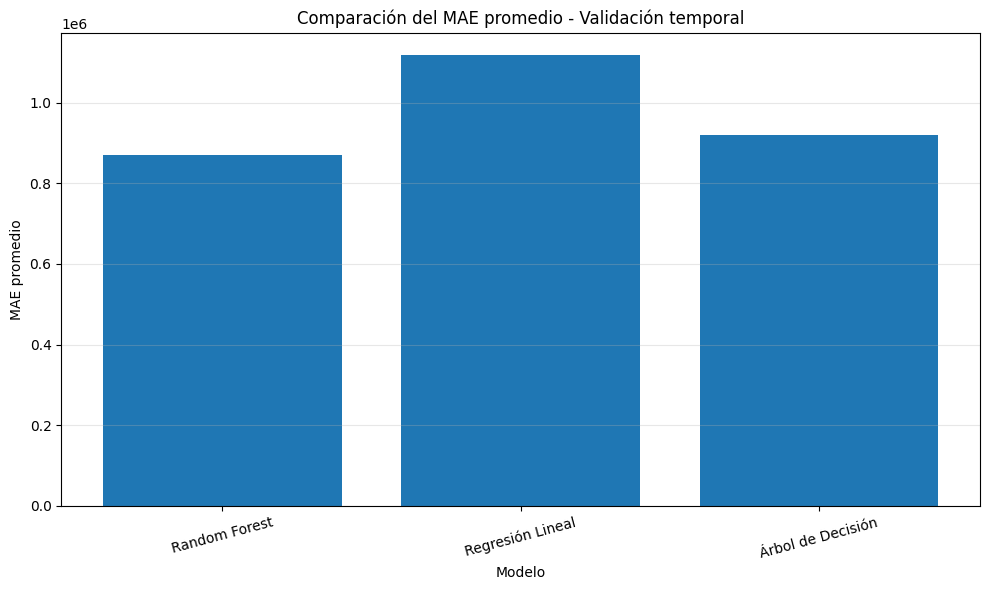

In [ ]:
# Importar la biblioteca Matplotlib para crear gráficos.
import matplotlib.pyplot as plt

# Crear una figura de 10 pulgadas de ancho por 6 pulgadas de alto.
plt.figure(figsize=(10, 6))

plt.bar(
    tabla_comparacion["Modelo"],
    tabla_comparacion["MAE"]
)

plt.title("Comparación del MAE promedio - Validación temporal")
plt.xlabel("Modelo")
plt.ylabel("MAE promedio")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:** La gráfica presenta el MAE promedio obtenido por los tres modelos durante los tres folds de validación temporal. Se observa que los valores se encuentran aproximadamente entre 871.675 y 1.117.820. Random Forest registra un MAE promedio de 871.675,56, el Árbol de Decisión 919.024,30 y la Regresión Lineal 1.117.819,80. La visualización permite identificar las diferencias en el error absoluto promedio de los modelos y facilita la comparación de su comportamiento durante la validación temporal. En términos del MAE, un valor menor representa un menor error absoluto promedio de predicción.

## 55. Gráfico comparativo de RMSE

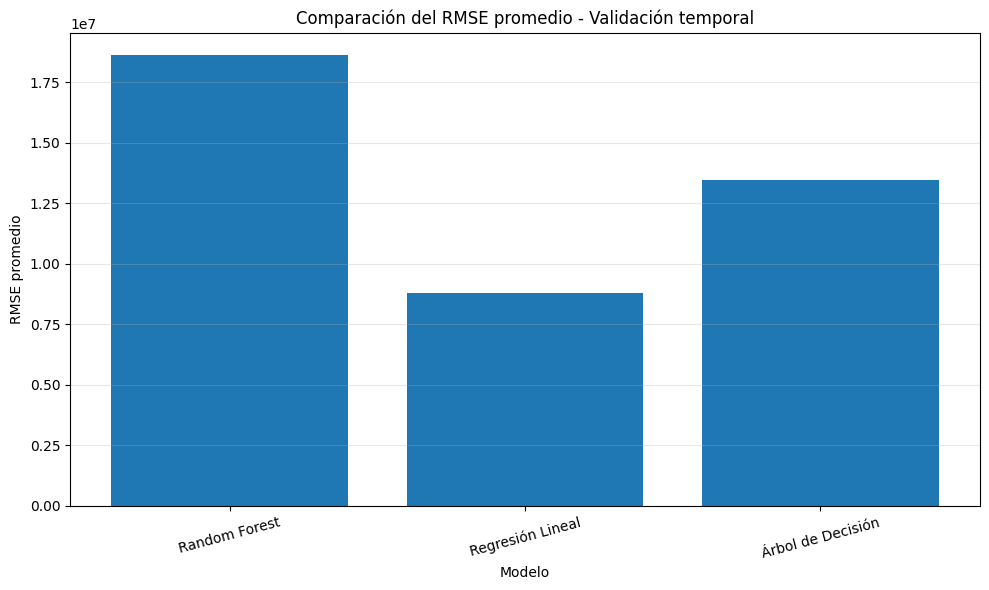

In [ ]:
# Crear una figura de 10 pulgadas de ancho por 6 pulgadas de alto.
plt.figure(figsize=(10, 6))

# Crear un gráfico de barras utilizando los nombres de los modelos
# y sus respectivos valores de RMSE promedio.
plt.bar(
    tabla_comparacion["Modelo"],
    tabla_comparacion["RMSE"]
)

# Establecer el título principal de la gráfica.
plt.title("Comparación del RMSE promedio - Validación temporal")

# Etiquetar el eje horizontal con el nombre de los modelos.
plt.xlabel("Modelo")

# Etiquetar el eje vertical indicando que representa el RMSE promedio.
plt.ylabel("RMSE promedio")

# Girar ligeramente las etiquetas del eje X
# para facilitar su lectura.
plt.xticks(rotation=15)

# Agregar una cuadrícula horizontal para facilitar
# la comparación de los valores del RMSE.
plt.grid(axis="y", alpha=0.3)

# Ajustar automáticamente los elementos de la gráfica
# para evitar que las etiquetas queden cortadas.
plt.tight_layout()

# Mostrar la gráfica en pantalla.
plt.show()

**Interpretación:** La gráfica presenta el RMSE promedio obtenido por los tres modelos durante los tres folds de validación temporal. La Regresión Lineal registra un RMSE promedio de 8.786.756,67, el Árbol de Decisión alcanza 13.453.536,91 y Random Forest presenta 18.622.327,61. La visualización evidencia diferencias en el nivel de error cuadrático entre los modelos. Debido a que el RMSE otorga mayor peso a los errores grandes, esta métrica permite analizar especialmente la presencia de desviaciones de mayor magnitud en las predicciones.

## 56. Gráfico comparativo de R²

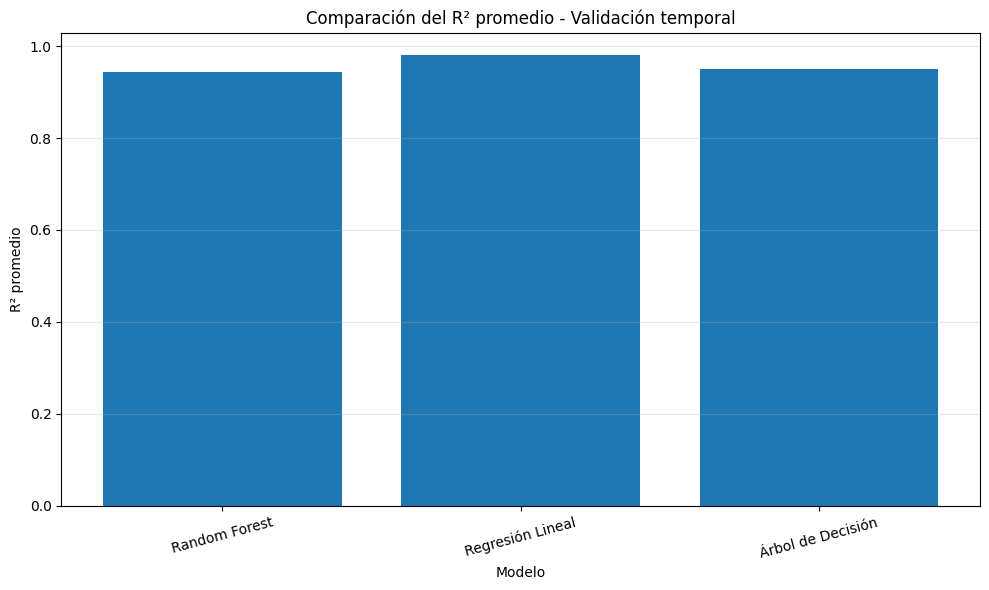

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    tabla_comparacion["Modelo"],
    tabla_comparacion["R2"]
)

plt.title("Comparación del R² promedio - Validación temporal")
plt.xlabel("Modelo")
plt.ylabel("R² promedio")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:* La gráfica muestra el R² promedio obtenido por los tres modelos durante los tres folds de validación temporal. La Regresión Lineal presenta un R² promedio de 0,9799, el Árbol de Decisión alcanza 0,9503 y Random Forest obtiene 0,9430. Los valores muestran que los tres modelos explican una proporción elevada de la variabilidad observada en la variable objetivo, aunque existen diferencias entre ellos. Esta métrica complementa el análisis realizado mediante MAE y RMSE, permitiendo evaluar el grado en que las predicciones representan la variabilidad de las ventas futuras.

## 57. Crear la tabla final de resultados

In [ ]:
# Resultados sobre el conjunto de prueba
tabla_prueba = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Árbol de Decisión",
        "Random Forest"
    ],
    "MAE_Prueba": [
        mae_regresion,
        mae_arbol,
        mae_rf
    ],
    "RMSE_Prueba": [
        rmse_regresion,
        rmse_arbol,
        rmse_rf
    ],
    "R2_Prueba": [
        r2_regresion,
        r2_arbol,
        r2_rf
    ]
})

# Resultados promedio de validación temporal
tabla_cv = tabla_comparacion.rename(columns={
    "MAE": "MAE_CV",
    "RMSE": "RMSE_CV",
    "R2": "R2_CV"
})

# Unir ambas tablas
tabla_resultados_final = pd.merge(
    tabla_prueba,
    tabla_cv,
    on="Modelo"
)

tabla_resultados_final = tabla_resultados_final.round(4)

print("TABLA FINAL DE EVALUACIÓN")
tabla_resultados_final

TABLA FINAL DE EVALUACIÓN


,Modelo,MAE_Prueba,RMSE_Prueba,R2_Prueba,MAE_CV,RMSE_CV,R2_CV
0,Regresión Lineal,1.537940e+06,1.005196e+07,0.9895,1117819.80,8786756.67,0.9799
1,Árbol de Decisión,1.494260e+06,1.013095e+07,0.9893,919024.30,13453536.91,0.9503
2,Random Forest,1.613874e+06,1.581843e+07,0.9739,871675.56,18622327.61,0.9430


**Interpretación:** La tabla final integra los resultados de evaluación de los tres modelos mediante las métricas MAE, RMSE y R², tanto para el conjunto de prueba como para la validación temporal. En la prueba de mayo, la Regresión Lineal obtuvo un MAE de 1.537.940,47, un RMSE de 10.051.963,07 y un R² de 0,9895; el Árbol de Decisión presentó 1.494.260,10, 10.130.947,86 y 0,9893, respectivamente; mientras que Random Forest registró 1.613.874,41, 15.818.427,15 y 0,9739. En la validación temporal, los valores promedio muestran diferencias adicionales entre los modelos, evidenciando que su comportamiento puede variar según el período evaluado y la métrica considerada. Esta tabla permite integrar ambas evaluaciones y proporciona una visión global del desempeño predictivo obtenido.

## 58. Generar la interpretación automática de resultados

In [ ]:
# Mostrar un encabezado para identificar la sección
# donde se presentan e interpretan los resultados.
print("=== INTERPRETACIÓN DE RESULTADOS ===\n")

# Recorrer cada fila de la tabla de resultados finales.
# Cada fila corresponde a uno de los modelos evaluados.
for _, fila in tabla_resultados_final.iterrows():

    print(f"Modelo: {fila['Modelo']}")
    print(f"  MAE prueba : {fila['MAE_Prueba']:,.2f}")
    print(f"  RMSE prueba: {fila['RMSE_Prueba']:,.2f}")
    print(f"  R² prueba  : {fila['R2_Prueba']:.4f}")
    print(f"  MAE CV     : {fila['MAE_CV']:,.2f}")
    print(f"  RMSE CV    : {fila['RMSE_CV']:,.2f}")
    print(f"  R² CV      : {fila['R2_CV']:.4f}")
    print()

=== INTERPRETACIÓN DE RESULTADOS ===

Modelo: Regresión Lineal
  MAE prueba : 1,537,940.47
  RMSE prueba: 10,051,963.07
  R² prueba  : 0.9895
  MAE CV     : 1,117,819.80
  RMSE CV    : 8,786,756.67
  R² CV      : 0.9799

Modelo: Árbol de Decisión
  MAE prueba : 1,494,260.10
  RMSE prueba: 10,130,947.86
  R² prueba  : 0.9893
  MAE CV     : 919,024.30
  RMSE CV    : 13,453,536.91
  R² CV      : 0.9503

Modelo: Random Forest
  MAE prueba : 1,613,874.41
  RMSE prueba: 15,818,427.15
  R² prueba  : 0.9739
  MAE CV     : 871,675.56
  RMSE CV    : 18,622,327.61
  R² CV      : 0.9430



**Interpretación:** La evaluación final permitió analizar el desempeño de los tres modelos mediante MAE, RMSE y R², considerando tanto el conjunto de prueba como la validación temporal. En el conjunto de prueba, los modelos presentan valores de R² entre 0,9739 y 0,9895, mientras que en la validación temporal los valores promedio se encuentran entre 0,9430 y 0,9799. Los valores de MAE y RMSE evidencian diferencias en la magnitud de los errores según el modelo y el período evaluado. En consecuencia, los resultados muestran que el desempeño predictivo debe analizarse de manera conjunta mediante las tres métricas y considerando tanto la evaluación sobre datos de prueba como la validación temporal.

###59. Generar una tabla lista para el informe

In [ ]:
# Crear una copia de la tabla de resultados finales.
# Se utiliza una copia para no modificar la tabla original.
tabla_informe = tabla_resultados_final.copy()

# Formatear el MAE del conjunto de prueba.
# Se agregan separadores de miles y dos decimales.
tabla_informe["MAE_Prueba"] = tabla_informe["MAE_Prueba"].map(
    lambda x: f"{x:,.2f}"
)

# Formatear el RMSE del conjunto de prueba.
# Se agregan separadores de miles y dos decimales.
tabla_informe["RMSE_Prueba"] = tabla_informe["RMSE_Prueba"].map(
    lambda x: f"{x:,.2f}"
)

# Formatear el R² del conjunto de prueba.
# Se muestran cuatro cifras decimales.
tabla_informe["R2_Prueba"] = tabla_informe["R2_Prueba"].map(
    lambda x: f"{x:.4f}"
)

# Formatear el MAE obtenido durante la validación temporal.
# Se agregan separadores de miles y dos decimales.
tabla_informe["MAE_CV"] = tabla_informe["MAE_CV"].map(
    lambda x: f"{x:,.2f}"
)

# Formatear el RMSE obtenido durante la validación temporal.
# Se agregan separadores de miles y dos decimales.
tabla_informe["RMSE_CV"] = tabla_informe["RMSE_CV"].map(
    lambda x: f"{x:,.2f}"
)

# Formatear el R² obtenido durante la validación temporal.
# Se muestran cuatro cifras decimales.
tabla_informe["R2_CV"] = tabla_informe["R2_CV"].map(
    lambda x: f"{x:.4f}"
)

# Mostrar la tabla con las métricas formateadas
# para facilitar su incorporación al informe.
tabla_informe

,Modelo,MAE_Prueba,RMSE_Prueba,R2_Prueba,MAE_CV,RMSE_CV,R2_CV
0,Regresión Lineal,"1,537,940.47","10,051,963.07",0.9895,"1,117,819.80","8,786,756.67",0.9799
1,Árbol de Decisión,"1,494,260.10","10,130,947.86",0.9893,"919,024.30","13,453,536.91",0.9503
2,Random Forest,"1,613,874.41","15,818,427.15",0.9739,"871,675.56","18,622,327.61",0.9430


**Interpretación:** La tabla final permite comparar el desempeño de los modelos Regresión Lineal, Árbol de Decisión y Random Forest mediante las métricas MAE, RMSE y R², tanto en el conjunto de prueba como en la validación temporal. En la prueba, los tres modelos presentan valores de R² superiores a 0,97, mientras que los valores de MAE y RMSE muestran diferencias en el nivel de error de las predicciones. En la validación temporal también se observan variaciones entre las métricas, lo que evidencia que el comportamiento de los modelos cambia según el período evaluado. Por ello, la evaluación conjunta de prueba y validación temporal proporciona una visión más completa del desempeño predictivo.

##60. Crear y descargar el modelo completo para la API

In [ ]:
import joblib

# ==========================================
# 1. Preparar datos de entrenamiento
# ==========================================

columnas_excluir_api = [
    "TOTAL_VENTAS_FUTURA",
    "MES_FUTURO",
    "AÑO_FUTURO",
    "CRECIMIENTO_VENTAS"
]

X_api = df_train.drop(
    columns=columnas_excluir_api
)

y_api = df_train["TOTAL_VENTAS_FUTURA"]


# ==========================================
# 2. Crear pipeline completo
# ==========================================

pipeline_api = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])


# ==========================================
# 3. Entrenar con todo el conjunto
#    de entrenamiento enero-abril
# ==========================================

print("Entrenando modelo final para API...")

pipeline_api.fit(
    X_api,
    y_api
)

print("Modelo entrenado correctamente.")


# ==========================================
# 4. Guardar modelo
# ==========================================

ruta_modelo = "/content/modelo_ventas_api.joblib"

joblib.dump(
    pipeline_api,
    ruta_modelo
)

print("\nModelo guardado en:")
print(ruta_modelo)


# ==========================================
# 5. Comprobar que el archivo existe
# ==========================================

import os

print("\nTamaño del archivo:")
print(round(os.path.getsize(ruta_modelo) / (1024 * 1024), 2), "MB")

Entrenando modelo final para API...
Modelo entrenado correctamente.

Modelo guardado en:
/content/modelo_ventas_api.joblib

Tamaño del archivo:
9.91 MB


In [ ]:
# Importar la función files de Google Colab,
# que permite descargar archivos desde el entorno de ejecución.
from google.colab import files

# Descargar el archivo del modelo entrenado.
# Se utiliza la ruta donde fue guardado anteriormente.
files.download("/content/modelo_ventas_api.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>